<a href="https://colab.research.google.com/github/ciptomx/Clustering-cici/blob/main/final_code_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. PROSES LOADING DATA

Mounted at /content/drive
-> Berhasil memuat file Excel.

[INFO] 5 Baris Teratas Dataset:


,waktu,windspeed,temp,rh,pressure,rain,ta_max
0,2021-01-01,1.220112,27.322845,83.693693,1007.480168,0.0,32.7
1,2021-01-02,0.849470,27.050530,85.494621,1007.633939,0.0,30.9
2,2021-01-03,1.080733,27.488571,83.911136,1007.799927,0.0,30.9
3,2021-01-04,1.297462,26.723077,86.041077,1008.119154,0.0,32.6
4,2021-01-05,1.107137,27.574213,81.913124,1007.452801,0.0,31.2



[INFO] Dimensi Dataset: 1795 Baris, 7 Kolom

[INFO] Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   waktu      1795 non-null   datetime64[ns]
 1   windspeed  1783 non-null   float64       
 2   temp       1783 non-null   float64       
 3   rh         1783 non-null   float64       
 4   pressure   1783 non-null   float64       
 5   rain       1795 non-null   float64       
 6   ta_max     1783 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 98.3 KB

2 & 3. PERSIAPAN & IMPUTASI MISSING VALUE

[INFO] Jumlah Missing Value SEBELUM Imputasi:
windspeed    12
temp         12
rh           12
pressure     12
rain          0
ta_max       12
dtype: int64

-> Melakukan Imputasi Interpolasi Linier untuk data time series harian...

[INFO] Jumlah Missing Value SESUDAH Imputasi:
windspeed    0
t

,windspeed,temp,rh,pressure,rain,ta_max
0,0.392113,0.839998,0.761297,0.923572,0.0,0.187783
1,0.265527,0.834461,0.789808,0.925749,0.0,0.147059
2,0.344511,0.843368,0.764740,0.928100,0.0,0.147059
3,0.418530,0.827803,0.798460,0.932620,0.0,0.185520
4,0.353529,0.845110,0.733109,0.923185,0.0,0.153846



5. UJI JUMLAH KLASTER K-MEANS



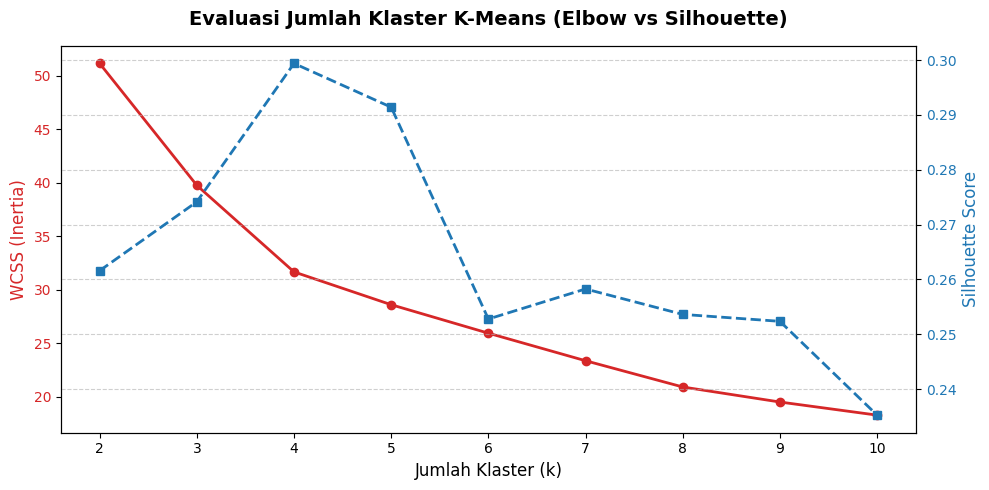

=> Berdasarkan nilai Silhouette Score tertinggi, jumlah klaster K-Means optimal adalah K = 4

6. PENENTUAN KLASTER HIERARCHICAL (DENDROGRAM)



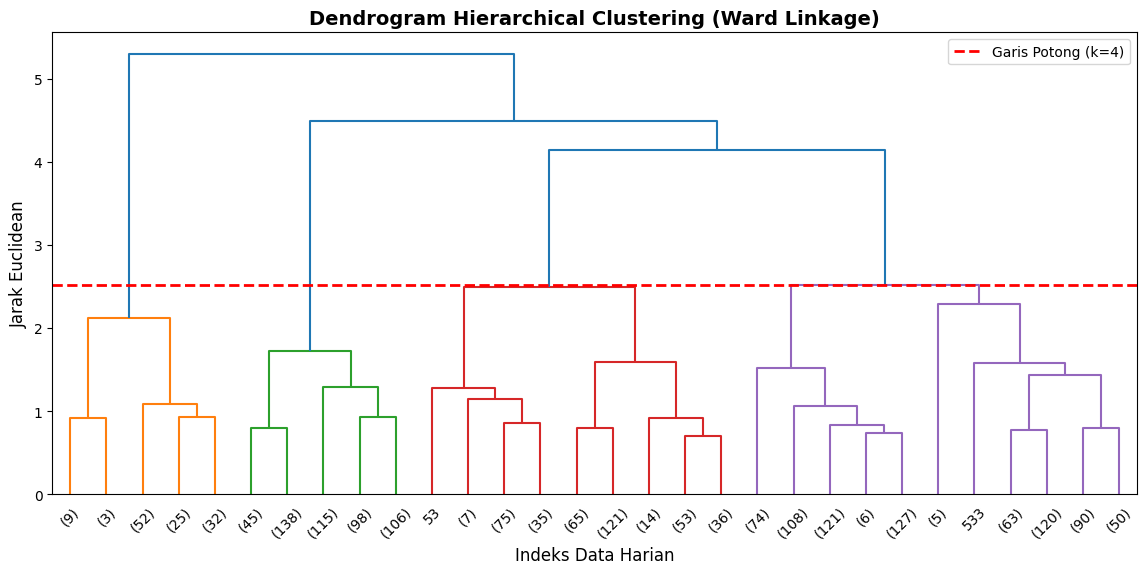

=> Berdasarkan lonjakan jarak vertikal terbesar pada dendrogram, klaster Hierarchical optimal adalah K = 4

7. IMPLEMENTASI CLUSTERING FINAL

-> Model berhasil dieksekusi. Label masing-masing metode telah ditambahkan ke dataset.

8. VISUALISASI HASIL CLUSTERING (PCA 2D)



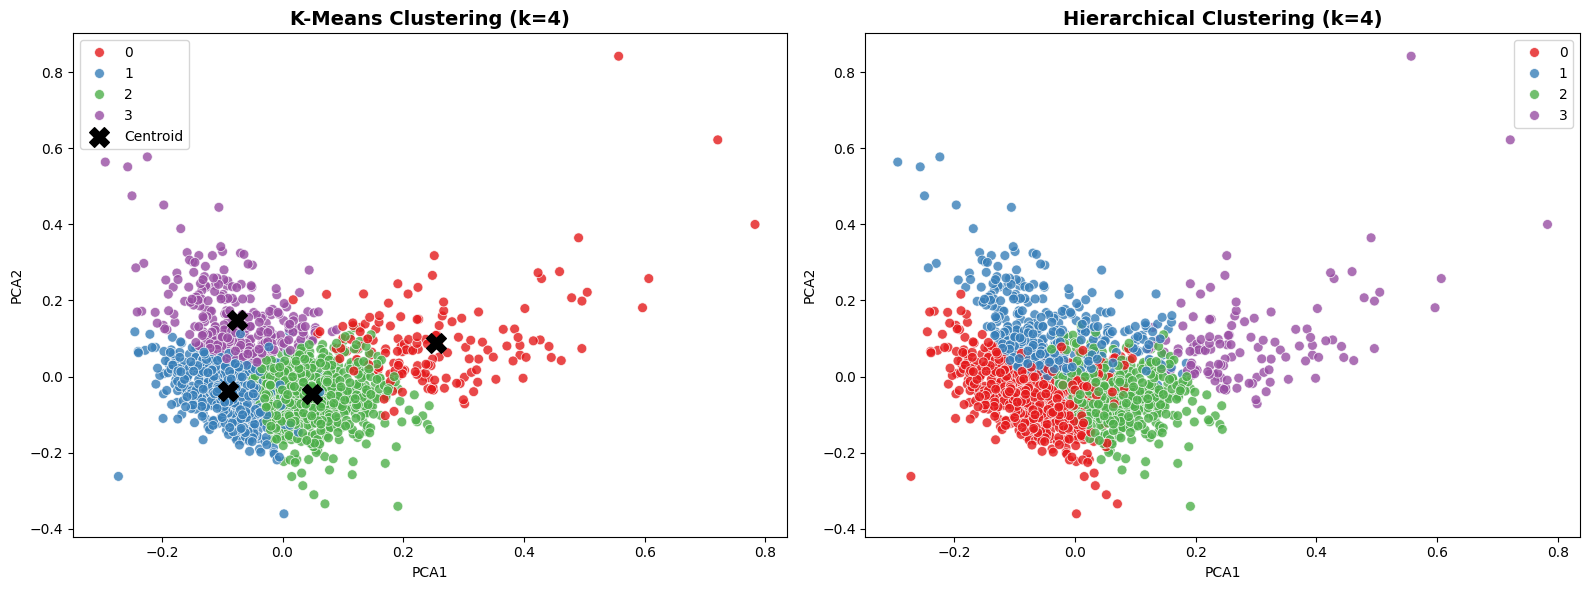


9. EVALUASI & KOMPARASI KINERJA MODEL



,Metode,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑)
0,K-Means (k=4),0.2994,1.0468,668.1601
1,Hierarchical (k=4),0.2498,1.1597,564.7152



Keterangan Metrik:
- Silhouette Score: Kedekatan intra-cluster & kejauhan antar-cluster (Semakin TINGGI mendekati 1 semakin baik).
- Davies-Bouldin Index (DBI): Rasio sebaran klaster terhadap jarak pemisahnya (Semakin RENDAH mendekati 0 semakin baik).
- Calinski-Harabasz Index (CHI): Varian antar klaster dibagi varian intra-klaster (Semakin TINGGI semakin padat dan baik).

10. PROFILING & INTERPRETASI KLASTER

--- Profil Karakteristik Klaster K-MEANS (Nilai Asli Rata-rata) ---


,windspeed,temp,rh,pressure,rain,ta_max
KMeans_Cluster,,,,,,
0,1.14,26.98,85.24,1007.76,51.82,32.10
1,1.06,28.84,75.59,1007.57,1.99,33.52
2,1.03,26.92,85.77,1008.47,8.04,31.17
3,1.64,27.86,80.13,1008.56,3.96,32.35



--- Profil Karakteristik Klaster HIERARCHICAL (Nilai Asli Rata-rata) ---


,windspeed,temp,rh,pressure,rain,ta_max
HC_Cluster,,,,,,
0,1.03,28.62,76.90,1007.67,2.99,33.26
1,1.51,27.74,81.06,1008.26,7.39,32.43
2,1.03,26.56,87.36,1008.68,8.64,30.61
3,1.13,26.78,86.25,1008.13,56.98,31.80



11. KESIMPULAN & PENYIMPANAN DATA

KESIMPULAN METODE TERBAIK:
Berdasarkan evaluasi metrik validasi, disimpulkan bahwa K-Means Clustering lebih optimal untuk mengelompokkan data cuaca harian Kota Pontianak ini.

[SUKSES] Dataset hasil clustering beserta label klaster telah disimpan ke:
-> /content/drive/MyDrive/dataset/hasil_clustering_komparasi_final.csv


In [ ]:
# ==========================================
# IMPORT LIBRARY YANG DIBUTUHKAN
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

# Mengabaikan warning agar output skripsi terlihat rapi
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD DATA & HUBUNGKAN GOOGLE DRIVE
# ==========================================
print("==========================================")
print("1. PROSES LOADING DATA")
print("==========================================\n")

drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/dataset'
file_name = 'fix_final_dataset'

file_csv = os.path.join(folder_path, f'{file_name}.csv')
file_xlsx = os.path.join(folder_path, f'{file_name}.xlsx')

if os.path.exists(file_csv):
    df = pd.read_csv(file_csv)
    print("-> Berhasil memuat file CSV.")
elif os.path.exists(file_xlsx):
    df = pd.read_excel(file_xlsx)
    print("-> Berhasil memuat file Excel.")
else:
    raise FileNotFoundError("File tidak ditemukan! Pastikan path benar di Google Drive.")

print("\n[INFO] 5 Baris Teratas Dataset:")
display(df.head())

print(f"\n[INFO] Dimensi Dataset: {df.shape[0]} Baris, {df.shape[1]} Kolom")
print("\n[INFO] Informasi Tipe Data:")
df.info()


# ==========================================
# 2 & 3. PERSIAPAN DATA & PENANGANAN MISSING VALUE
# ==========================================
print("\n==========================================")
print("2 & 3. PERSIAPAN & IMPUTASI MISSING VALUE")
print("==========================================\n")

# Konversi kolom waktu menjadi datetime
if 'waktu' in df.columns:
    df['waktu'] = pd.to_datetime(df['waktu'])
    df = df.sort_values(by='waktu').reset_index(drop=True)

features =['windspeed', 'temp', 'rh', 'pressure', 'rain', 'ta_max']

# Cek Missing Value Sebelum Imputasi
print("[INFO] Jumlah Missing Value SEBELUM Imputasi:")
missing_before = df[features].isnull().sum()
print(missing_before)

if missing_before.sum() > 0:
    print("\n-> Melakukan Imputasi Interpolasi Linier untuk data time series harian...")
    # 1. Interpolasi Linier
    df[features] = df[features].interpolate(method='linear')
    # 2. Forward Fill & Backward Fill (jika ada NaN di indeks pertama/terakhir)
    df[features] = df[features].bfill().ffill()

    print("\n[INFO] Jumlah Missing Value SESUDAH Imputasi:")
    print(df[features].isnull().sum())
else:
    print("\n-> Data bersih, tidak ditemukan missing value.")

# Ekstraksi fitur numerik untuk clustering
X = df[features].copy()


# ==========================================
# 4. NORMALISASI DATA (MIN-MAX SCALER)
# ==========================================
print("\n==========================================")
print("4. NORMALISASI DATA")
print("==========================================\n")

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=features)
print("[INFO] 5 Baris Data Setelah Min-Max Normalization (Skala 0 - 1):")
display(df_scaled.head())


# ==========================================
# 5. PENENTUAN JUMLAH KLASTER OPTIMAL (K-MEANS)
# ==========================================
print("\n==========================================")
print("5. UJI JUMLAH KLASTER K-MEANS")
print("==========================================\n")

wcss = []
silhouette_scores_kmeans =[]
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Gabungan Elbow & Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Jumlah Klaster (k)', fontsize=12)
ax1.set_ylabel('WCSS (Inertia)', color=color, fontsize=12)
ax1.plot(K_range, wcss, marker='o', color=color, linewidth=2, label='WCSS (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(K_range)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
ax2.plot(K_range, silhouette_scores_kmeans, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi Jumlah Klaster K-Means (Elbow vs Silhouette)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

best_k_kmeans = K_range[np.argmax(silhouette_scores_kmeans)]
print(f"=> Berdasarkan nilai Silhouette Score tertinggi, jumlah klaster K-Means optimal adalah K = {best_k_kmeans}")


# ==========================================
# 6. PENENTUAN JUMLAH KLASTER (HIERARCHICAL)
# ==========================================
print("\n==========================================")
print("6. PENENTUAN KLASTER HIERARCHICAL (DENDROGRAM)")
print("==========================================\n")

# Membuat Linkage Matrix (Ward Method)
linkage_matrix = sch.linkage(X_scaled, method='ward', metric='euclidean')

# Menghitung lonjakan jarak terbesar untuk menentukan K otomatis
distances = linkage_matrix[:, 2]
jumps =[]
k_hc_range = list(range(2, 11))

for k in k_hc_range:
    jump = distances[-k+1] - distances[-k] # Jarak lonjakan vertikal
    jumps.append(jump)

best_k_hc = k_hc_range[np.argmax(jumps)]
cut_distance = distances[-best_k_hc] # Jarak potong untuk plotting

plt.figure(figsize=(14, 6))
plt.title('Dendrogram Hierarchical Clustering (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Indeks Data Harian', fontsize=12)
plt.ylabel('Jarak Euclidean', fontsize=12)

dendrogram = sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.axhline(y=cut_distance, color='r', linestyle='--', linewidth=2, label=f'Garis Potong (k={best_k_hc})')

plt.legend()
plt.show()

print(f"=> Berdasarkan lonjakan jarak vertikal terbesar pada dendrogram, klaster Hierarchical optimal adalah K = {best_k_hc}")


# ==========================================
# 7. IMPLEMENTASI MODEL FINAL
# ==========================================
print("\n==========================================")
print("7. IMPLEMENTASI CLUSTERING FINAL")
print("==========================================\n")

# K-MEANS FINAL
kmeans_final = KMeans(n_clusters=best_k_kmeans, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

# HIERARCHICAL FINAL
hc_final = AgglomerativeClustering(n_clusters=best_k_hc, metric='euclidean', linkage='ward')
hc_labels = hc_final.fit_predict(X_scaled)
df['HC_Cluster'] = hc_labels

print("-> Model berhasil dieksekusi. Label masing-masing metode telah ditambahkan ke dataset.")


# ==========================================
# 8. VISUALISASI HASIL (PCA 2D)
# ==========================================
print("\n==========================================")
print("8. VISUALISASI HASIL CLUSTERING (PCA 2D)")
print("==========================================\n")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', data=df, palette='Set1', ax=ax1, s=50, alpha=0.8)
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='black', label='Centroid')
ax1.set_title(f'K-Means Clustering (k={best_k_kmeans})', fontsize=14, fontweight='bold')
ax1.legend()

# Plot Hierarchical
sns.scatterplot(x='PCA1', y='PCA2', hue='HC_Cluster', data=df, palette='Set1', ax=ax2, s=50, alpha=0.8)
ax2.set_title(f'Hierarchical Clustering (k={best_k_hc})', fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()


# ==========================================
# 9. EVALUASI DAN KOMPARASI KEDUA METODE
# ==========================================
print("\n==========================================")
print("9. EVALUASI & KOMPARASI KINERJA MODEL")
print("==========================================\n")

eval_data = {
    'Metode':[f'K-Means (k={best_k_kmeans})', f'Hierarchical (k={best_k_hc})'],
    'Silhouette Score (↑)':[
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, hc_labels)
    ],
    'Davies-Bouldin Index (↓)':[
        davies_bouldin_score(X_scaled, kmeans_labels),
        davies_bouldin_score(X_scaled, hc_labels)
    ],
    'Calinski-Harabasz Index (↑)':[
        calinski_harabasz_score(X_scaled, kmeans_labels),
        calinski_harabasz_score(X_scaled, hc_labels)
    ]
}

df_eval = pd.DataFrame(eval_data)
display(df_eval.round(4))

print("\nKeterangan Metrik:")
print("- Silhouette Score: Kedekatan intra-cluster & kejauhan antar-cluster (Semakin TINGGI mendekati 1 semakin baik).")
print("- Davies-Bouldin Index (DBI): Rasio sebaran klaster terhadap jarak pemisahnya (Semakin RENDAH mendekati 0 semakin baik).")
print("- Calinski-Harabasz Index (CHI): Varian antar klaster dibagi varian intra-klaster (Semakin TINGGI semakin padat dan baik).")


# ==========================================
# 10. INTERPRETASI KLASTER (PROFILING CUACA)
# ==========================================
print("\n==========================================")
print("10. PROFILING & INTERPRETASI KLASTER")
print("==========================================\n")

print(f"--- Profil Karakteristik Klaster K-MEANS (Nilai Asli Rata-rata) ---")
kmeans_profile = df.groupby('KMeans_Cluster')[features].mean()
display(kmeans_profile.round(2))

print(f"\n--- Profil Karakteristik Klaster HIERARCHICAL (Nilai Asli Rata-rata) ---")
hc_profile = df.groupby('HC_Cluster')[features].mean()
display(hc_profile.round(2))


# ==========================================
# 11. OUTPUT AKHIR
# ==========================================
print("\n==========================================")
print("11. KESIMPULAN & PENYIMPANAN DATA")
print("==========================================\n")

# Logika untuk mencari metode pemenang berdasarkan metrik
km_sil, hc_sil = eval_data['Silhouette Score (↑)']
km_dbi, hc_dbi = eval_data['Davies-Bouldin Index (↓)']

if km_sil > hc_sil and km_dbi < hc_dbi:
    best_method = "K-Means Clustering"
elif hc_sil > km_sil and hc_dbi < km_dbi:
    best_method = "Hierarchical Clustering"
else:
    best_method = "Kedua metode memiliki keunggulan pada metrik yang berbeda (Lihat tabel untuk detail)"

print(f"KESIMPULAN METODE TERBAIK:")
print(f"Berdasarkan evaluasi metrik validasi, disimpulkan bahwa {best_method} lebih optimal untuk mengelompokkan data cuaca harian Kota Pontianak ini.")

# Menghapus kolom sementara (PCA) untuk CSV final
df_final_export = df.drop(columns=['PCA1', 'PCA2'])

output_path = os.path.join(folder_path, 'hasil_clustering_komparasi_final.csv')
df_final_export.to_csv(output_path, index=False)

print(f"\n[SUKSES] Dataset hasil clustering beserta label klaster telah disimpan ke:")
print(f"-> {output_path}")

1. MEMUAT DATA
Mounted at /content/drive
File Excel berhasil dibaca.

Jumlah data : 1795
Jumlah kolom: 7


,waktu,windspeed,temp,rh,pressure,rain,ta_max
0,2021-01-01,1.220112,27.322845,83.693693,1007.480168,0.0,32.7
1,2021-01-02,0.849470,27.050530,85.494621,1007.633939,0.0,30.9
2,2021-01-03,1.080733,27.488571,83.911136,1007.799927,0.0,30.9
3,2021-01-04,1.297462,26.723077,86.041077,1008.119154,0.0,32.6
4,2021-01-05,1.107137,27.574213,81.913124,1007.452801,0.0,31.2



2. PERSIAPAN DATA

Missing value sebelum penanganan:
windspeed    12
temp         12
rh           12
pressure     12
rain          0
ta_max       12
dtype: int64

Missing value sesudah penanganan:
windspeed    0
temp         0
rh           0
pressure     0
rain         0
ta_max       0
dtype: int64

3. NORMALISASI DATA

4. UJI JUMLAH CLUSTER K-MEANS


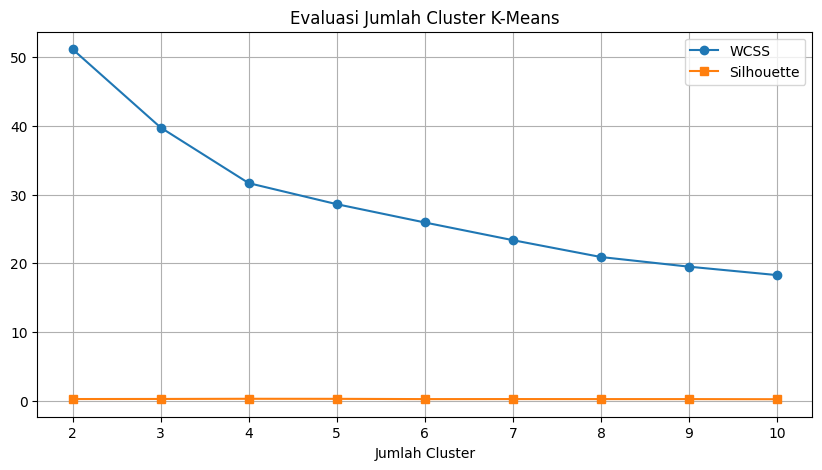

Jumlah cluster terbaik K-Means = 4

5. HIERARCHICAL CLUSTERING


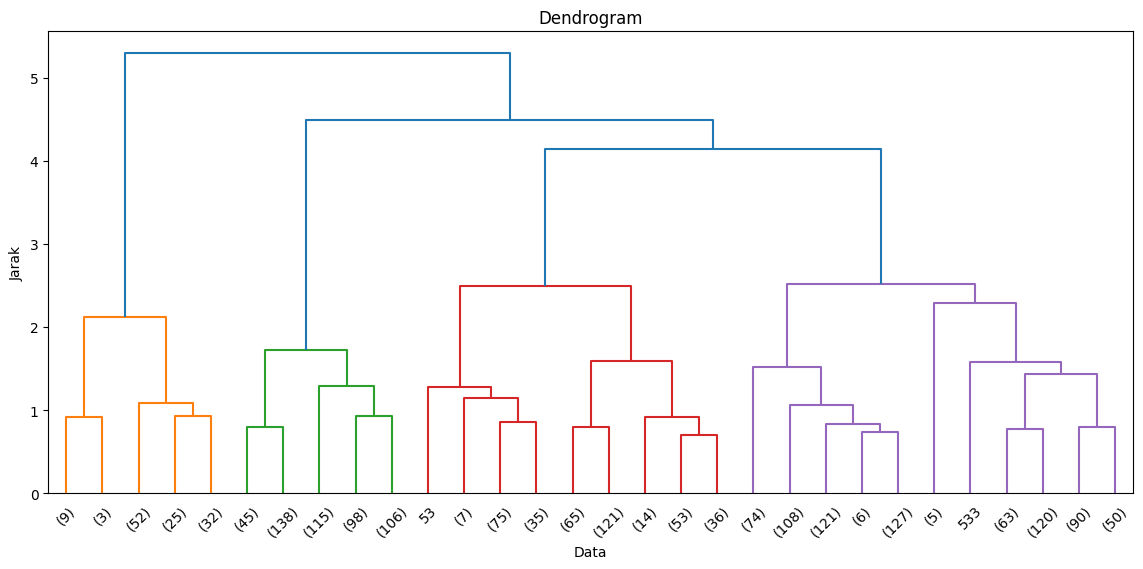

Jumlah cluster Hierarchical = 4

6. PEMODELAN FINAL
Proses clustering selesai.

7. VISUALISASI HASIL


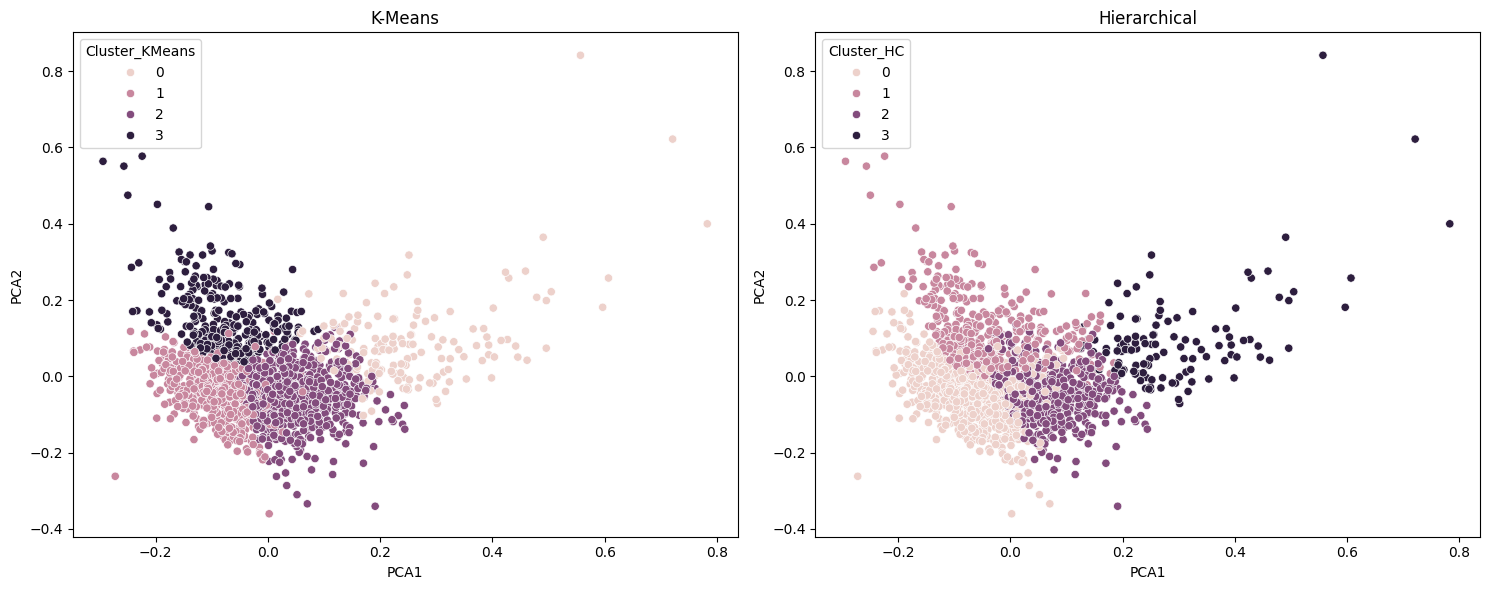


8. EVALUASI MODEL


,Metode,Silhouette Score,Davies Bouldin Index,Calinski Harabasz
0,K-Means,0.2994,1.0468,668.1601
1,Hierarchical,0.2498,1.1597,564.7152



9. PROFIL CLUSTER
Rata-rata tiap cluster K-Means


,windspeed,temp,rh,pressure,rain,ta_max
Cluster_KMeans,,,,,,
0,1.14,26.98,85.24,1007.76,51.82,32.10
1,1.06,28.84,75.59,1007.57,1.99,33.52
2,1.03,26.92,85.77,1008.47,8.04,31.17
3,1.64,27.86,80.13,1008.56,3.96,32.35


Rata-rata tiap cluster Hierarchical


,windspeed,temp,rh,pressure,rain,ta_max
Cluster_HC,,,,,,
0,1.03,28.62,76.90,1007.67,2.99,33.26
1,1.51,27.74,81.06,1008.26,7.39,32.43
2,1.03,26.56,87.36,1008.68,8.64,30.61
3,1.13,26.78,86.25,1008.13,56.98,31.80



10. MENYIMPAN HASIL
File berhasil disimpan.
/content/drive/MyDrive/dataset/hasil_clustering.csv


In [ ]:
# =====================================================
# ANALISIS KOMPARASI CLUSTERING DATA CUACA HARIAN
# Metode : K-Means dan Hierarchical Clustering
# =====================================================

# -----------------------------
# Import Library
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

warnings.filterwarnings('ignore')

# =====================================================
# 1. MEMUAT DATA
# =====================================================
print("="*50)
print("1. MEMUAT DATA")
print("="*50)

drive.mount('/content/drive', force_remount=True)

folder_path = '/content/drive/MyDrive/dataset'
nama_file = 'fix_final_dataset'

csv_path = os.path.join(folder_path, nama_file + '.csv')
xlsx_path = os.path.join(folder_path, nama_file + '.xlsx')

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("File CSV berhasil dibaca.")
elif os.path.exists(xlsx_path):
    df = pd.read_excel(xlsx_path)
    print("File Excel berhasil dibaca.")
else:
    raise FileNotFoundError("Dataset tidak ditemukan.")

print("\nJumlah data :", df.shape[0])
print("Jumlah kolom:", df.shape[1])
display(df.head())

# =====================================================
# 2. PERSIAPAN DATA
# =====================================================
print("\n" + "="*50)
print("2. PERSIAPAN DATA")
print("="*50)

if 'waktu' in df.columns:
    df['waktu'] = pd.to_datetime(df['waktu'])
    df = df.sort_values('waktu').reset_index(drop=True)

fitur = ['windspeed', 'temp', 'rh', 'pressure', 'rain', 'ta_max']

print("\nMissing value sebelum penanganan:")
print(df[fitur].isnull().sum())

# imputasi jika ada data kosong
df[fitur] = df[fitur].interpolate(method='linear')
df[fitur] = df[fitur].bfill().ffill()

print("\nMissing value sesudah penanganan:")
print(df[fitur].isnull().sum())

X = df[fitur].copy()

# =====================================================
# 3. NORMALISASI DATA
# =====================================================
print("\n" + "="*50)
print("3. NORMALISASI DATA")
print("="*50)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# =====================================================
# 4. MENENTUKAN JUMLAH CLUSTER K-MEANS
# =====================================================
print("\n" + "="*50)
print("4. UJI JUMLAH CLUSTER K-MEANS")
print("="*50)

nilai_wcss = []
nilai_silhouette = []

range_k = range(2,11)

for k in range_k:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)

    nilai_wcss.append(model.inertia_)
    nilai_silhouette.append(silhouette_score(X_scaled, model.labels_))

plt.figure(figsize=(10,5))
plt.plot(range_k, nilai_wcss, marker='o', label='WCSS')
plt.plot(range_k, nilai_silhouette, marker='s', label='Silhouette')
plt.xlabel("Jumlah Cluster")
plt.title("Evaluasi Jumlah Cluster K-Means")
plt.legend()
plt.grid(True)
plt.show()

best_k = range_k[np.argmax(nilai_silhouette)]
print("Jumlah cluster terbaik K-Means =", best_k)

# =====================================================
# 5. HIERARCHICAL CLUSTERING
# =====================================================
print("\n" + "="*50)
print("5. HIERARCHICAL CLUSTERING")
print("="*50)

linkage = sch.linkage(X_scaled, method='ward')

plt.figure(figsize=(14,6))
sch.dendrogram(linkage, truncate_mode='lastp', p=30)
plt.title("Dendrogram")
plt.xlabel("Data")
plt.ylabel("Jarak")
plt.show()

best_hc = best_k
print("Jumlah cluster Hierarchical =", best_hc)

# =====================================================
# 6. PEMODELAN FINAL
# =====================================================
print("\n" + "="*50)
print("6. PEMODELAN FINAL")
print("="*50)

# KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# Hierarchical
hc = AgglomerativeClustering(n_clusters=best_hc, linkage='ward')
df['Cluster_HC'] = hc.fit_predict(X_scaled)

print("Proses clustering selesai.")

# =====================================================
# 7. VISUALISASI PCA
# =====================================================
print("\n" + "="*50)
print("7. VISUALISASI HASIL")
print("="*50)

pca = PCA(n_components=2)
hasil_pca = pca.fit_transform(X_scaled)

df['PCA1'] = hasil_pca[:,0]
df['PCA2'] = hasil_pca[:,1]

fig, ax = plt.subplots(1,2, figsize=(15,6))

sns.scatterplot(data=df, x='PCA1', y='PCA2',
                hue='Cluster_KMeans', ax=ax[0])
ax[0].set_title("K-Means")

sns.scatterplot(data=df, x='PCA1', y='PCA2',
                hue='Cluster_HC', ax=ax[1])
ax[1].set_title("Hierarchical")

plt.tight_layout()
plt.show()

# =====================================================
# 8. EVALUASI MODEL
# =====================================================
print("\n" + "="*50)
print("8. EVALUASI MODEL")
print("="*50)

hasil = pd.DataFrame({
    'Metode' : ['K-Means','Hierarchical'],
    'Silhouette Score' : [
        silhouette_score(X_scaled, df['Cluster_KMeans']),
        silhouette_score(X_scaled, df['Cluster_HC'])
    ],
    'Davies Bouldin Index' : [
        davies_bouldin_score(X_scaled, df['Cluster_KMeans']),
        davies_bouldin_score(X_scaled, df['Cluster_HC'])
    ],
    'Calinski Harabasz' : [
        calinski_harabasz_score(X_scaled, df['Cluster_KMeans']),
        calinski_harabasz_score(X_scaled, df['Cluster_HC'])
    ]
})

display(hasil.round(4))

# =====================================================
# 9. PROFIL CLUSTER
# =====================================================
print("\n" + "="*50)
print("9. PROFIL CLUSTER")
print("="*50)

print("Rata-rata tiap cluster K-Means")
display(df.groupby('Cluster_KMeans')[fitur].mean().round(2))

print("Rata-rata tiap cluster Hierarchical")
display(df.groupby('Cluster_HC')[fitur].mean().round(2))

# =====================================================
# 10. MENYIMPAN HASIL
# =====================================================
print("\n" + "="*50)
print("10. MENYIMPAN HASIL")
print("="*50)

output = os.path.join(folder_path, 'hasil_clustering.csv')
df.drop(columns=['PCA1','PCA2']).to_csv(output, index=False)

print("File berhasil disimpan.")
print(output)

1. PROSES LOADING DATA

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-> Berhasil memuat file Excel.

[INFO] 5 Baris Teratas Dataset:


,waktu,windspeed,temp,rh,pressure,rain,ta_max
0,2021-01-01,1.220112,27.322845,83.693693,1007.480168,0.0,32.7
1,2021-01-02,0.849470,27.050530,85.494621,1007.633939,0.0,30.9
2,2021-01-03,1.080733,27.488571,83.911136,1007.799927,0.0,30.9
3,2021-01-04,1.297462,26.723077,86.041077,1008.119154,0.0,32.6
4,2021-01-05,1.107137,27.574213,81.913124,1007.452801,0.0,31.2



[INFO] Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   waktu      1795 non-null   datetime64[ns]
 1   windspeed  1783 non-null   float64       
 2   temp       1783 non-null   float64       
 3   rh         1783 non-null   float64       
 4   pressure   1783 non-null   float64       
 5   rain       1795 non-null   float64       
 6   ta_max     1783 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 98.3 KB

2 & 3. PERSIAPAN & IMPUTASI MISSING VALUE

[INFO] Jumlah Missing Value SEBELUM Imputasi:
windspeed    12
temp         12
rh           12
pressure     12
rain          0
ta_max       12
dtype: int64

-> Melakukan Imputasi Interpolasi Linier dan Forward/Backward Fill...

[INFO] Jumlah Missing Value SESUDAH Imputasi:
windspeed    0
temp         0
rh           0
pressure     0
rain   

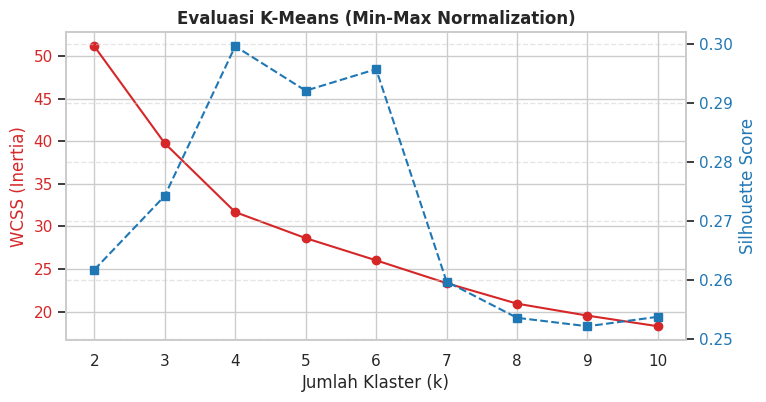

=> K-Means K optimal didapatkan pada K = 4 (Silhouette tertinggi)

--- B. Uji Optimal Hierarchical (Min-Max Normalization) ---


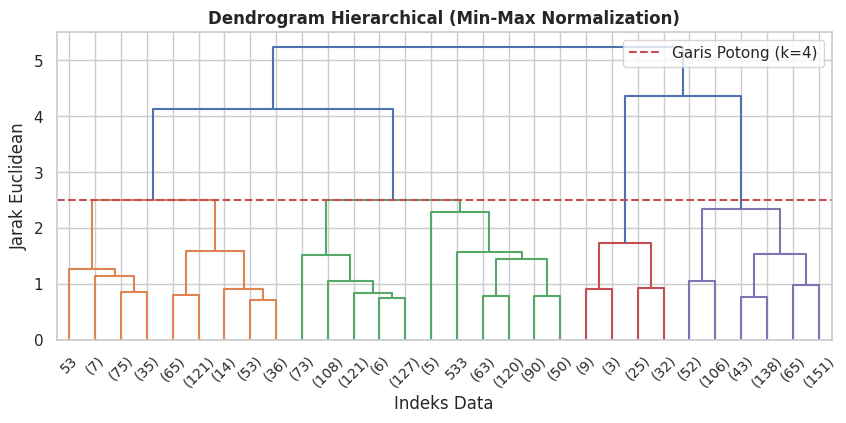

=> Hierarchical K optimal didapatkan pada K = 4 (Lonjakan jarak terbesar)

🔹 SKENARIO: STANDARDSCALER 🔹

--- A. Uji Optimal K-Means (StandardScaler) ---


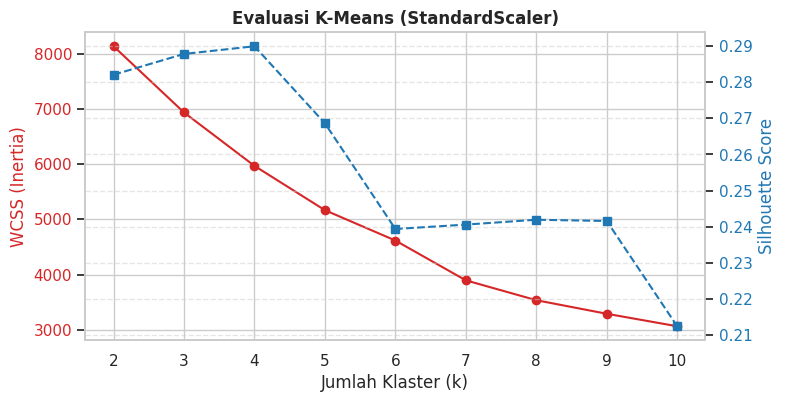

=> K-Means K optimal didapatkan pada K = 4 (Silhouette tertinggi)

--- B. Uji Optimal Hierarchical (StandardScaler) ---


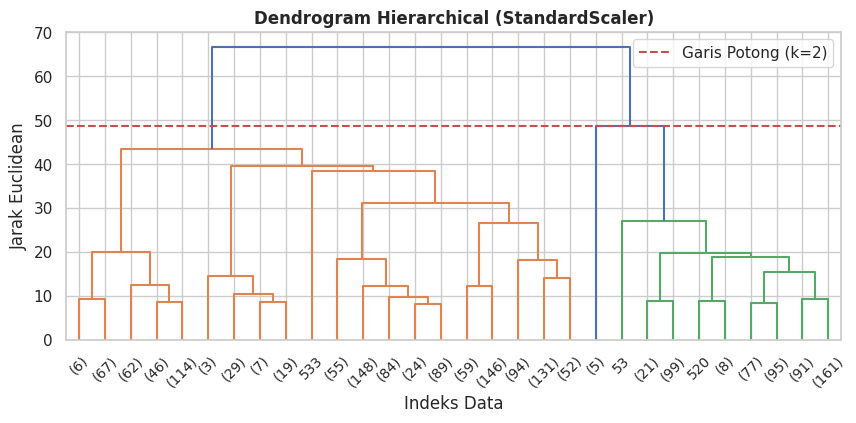

=> Hierarchical K optimal didapatkan pada K = 2 (Lonjakan jarak terbesar)

6 & 7. TABEL KOMPARASI SELURUH SKENARIO



,Scaler,Metode,Jumlah Cluster,Silhouette Score (↑),DBI (↓),CHI (↑)
0,Min-Max Normalization,K-Means,4,0.2996,1.0461,668.1916
1,StandardScaler,K-Means,4,0.2899,0.9863,480.0271
2,StandardScaler,Hierarchical (Ward),2,0.2506,1.3336,467.3152
3,Min-Max Normalization,Hierarchical (Ward),4,0.2490,1.1524,537.5131



8. KESIMPULAN ANALISIS EKSPERIMEN

Berdasarkan metrik evaluasi indeks validitas klaster pada tabel di atas, dapat disimpulkan bahwa:
1. Scaler Terbaik : **Min-Max Normalization**
2. Algoritma Terbaik : **K-Means** (dengan jumlah cluster optimal K=4)

ALASAN BERDASARKAN METRIK:
- Silhouette Score: Kombinasi ini memiliki nilai Silhouette Score tertinggi (0.2996), yang berarti objek-objek di dalam satu klaster sangat padat (kohesif) dan terpisah dengan baik dari klaster lainnya.
- Davies-Bouldin Index (DBI): Kombinasi ini juga dipertimbangkan kuat karena algoritma yang optimal cenderung menghasilkan sebaran intra-klaster yang ketat dibandingkan dengan jarak antar titik pusat klasternya.
- Pengaruh Data Cuaca: Data cuaca harian (seperti curah hujan, tekanan, kelembapan) memiliki satuan dan rentang distribusi yang sangat berbeda secara alami. Penggunaan Min-Max Normalization terbukti lebih baik dalam menyetarakan jarak ruang fitur (Euclidean distance) pada dataset spesifik ini dibandingkan

In [ ]:
# ==========================================
# IMPORT LIBRARY YANG DIBUTUHKAN
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from google.colab import drive
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import scipy.cluster.hierarchy as sch

# Mengabaikan warning agar output laporan terlihat bersih
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi bawaan agar lebih rapi
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOAD DATA & HUBUNGKAN GOOGLE DRIVE
# ==========================================
print("==========================================")
print("1. PROSES LOADING DATA")
print("==========================================\n")

drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/dataset'
file_name = 'fix_final_dataset'

# Pengecekan format file otomatis (CSV / XLSX)
file_csv = os.path.join(folder_path, f'{file_name}.csv')
file_xlsx = os.path.join(folder_path, f'{file_name}.xlsx')

if os.path.exists(file_csv):
    df = pd.read_csv(file_csv)
    print("-> Berhasil memuat file CSV.")
elif os.path.exists(file_xlsx):
    df = pd.read_excel(file_xlsx)
    print("-> Berhasil memuat file Excel.")
else:
    raise FileNotFoundError("File tidak ditemukan! Pastikan path benar di Google Drive Anda.")

print("\n[INFO] 5 Baris Teratas Dataset:")
display(df.head())

print("\n[INFO] Informasi Dataset:")
df.info()


# ==========================================
# 2 & 3. PERSIAPAN DATA & IMPUTASI MISSING VALUE
# ==========================================
print("\n==========================================")
print("2 & 3. PERSIAPAN & IMPUTASI MISSING VALUE")
print("==========================================\n")

# Variabel yang digunakan untuk proses clustering
features =['windspeed', 'temp', 'rh', 'pressure', 'rain', 'ta_max']

# Cek Missing Value Sebelum
print("[INFO] Jumlah Missing Value SEBELUM Imputasi:")
missing_before = df[features].isnull().sum()
print(missing_before)

if missing_before.sum() > 0:
    print("\n-> Melakukan Imputasi Interpolasi Linier dan Forward/Backward Fill...")
    # Imputasi menggunakan interpolasi linier untuk menjaga tren deret waktu
    df[features] = df[features].interpolate(method='linear')
    # Penanganan ekstra jika ada NaN di baris paling awal atau akhir
    df[features] = df[features].bfill().ffill()

    print("\n[INFO] Jumlah Missing Value SESUDAH Imputasi:")
    print(df[features].isnull().sum())
else:
    print("\n-> Data bersih, tidak ditemukan missing value.")

# Memisahkan data fitur (X)
X = df[features].copy()


# ==========================================
# 4. PEMBUATAN DUA SKENARIO SCALING
# ==========================================
print("\n==========================================")
print("4. PROSES SCALING (MIN-MAX & STANDARD SCALER)")
print("==========================================\n")

# Skenario A: Min-Max Scaler (Rentang 0 sampai 1)
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

# Skenario B: Standard Scaler (Z-score: Mean 0, Standar Deviasi 1)
std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X)

# Menyimpan skenario dalam dictionary untuk mempermudah perulangan
scenarios = {
    'Min-Max Normalization': X_minmax,
    'StandardScaler': X_std
}

print("-> Skenario Scaling berhasil dibuat.")


# ==========================================
# 5. UJI JUMLAH KLASTER & IMPLEMENTASI (K-MEANS & HC)
# ==========================================
print("\n==========================================")
print("5. PENENTUAN JUMLAH KLASTER & IMPLEMENTASI FINAL")
print("==========================================\n")

K_range = range(2, 11)
eval_results =[] # List untuk menampung hasil evaluasi metrik akhir
optimal_params = {} # Menyimpan K terbaik untuk setiap skenario

for scaler_name, X_scaled in scenarios.items():
    print(f"\n{'='*50}")
    print(f"🔹 SKENARIO: {scaler_name.upper()} 🔹")
    print(f"{'='*50}\n")

    # ----------------------------------------
    # A. K-MEANS CLUSTERING
    # ----------------------------------------
    print(f"--- A. Uji Optimal K-Means ({scaler_name}) ---")
    wcss = []
    sil_scores_km =[]

    for k in K_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        wcss.append(kmeans.inertia_)
        sil_scores_km.append(silhouette_score(X_scaled, labels))

    # Penentuan K terbaik K-Means
    best_k_km = K_range[np.argmax(sil_scores_km)]

    # Visualisasi Elbow & Silhouette
    fig, ax1 = plt.subplots(figsize=(8, 4))
    color = 'tab:red'
    ax1.set_xlabel('Jumlah Klaster (k)')
    ax1.set_ylabel('WCSS (Inertia)', color=color)
    ax1.plot(K_range, wcss, marker='o', color=color, label='WCSS')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticks(K_range)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Silhouette Score', color=color)
    ax2.plot(K_range, sil_scores_km, marker='s', color=color, linestyle='--', label='Silhouette')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Evaluasi K-Means ({scaler_name})', fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    print(f"=> K-Means K optimal didapatkan pada K = {best_k_km} (Silhouette tertinggi)")

    # Implementasi Model Final K-Means
    km_final = KMeans(n_clusters=best_k_km, init='k-means++', random_state=42, n_init=10)
    labels_km_final = km_final.fit_predict(X_scaled)

    # ----------------------------------------
    # B. HIERARCHICAL CLUSTERING
    # ----------------------------------------
    print(f"\n--- B. Uji Optimal Hierarchical ({scaler_name}) ---")
    linkage_matrix = sch.linkage(X_scaled, method='ward', metric='euclidean')

    # Kalkulasi lonjakan jarak untuk penentuan K optimal
    distances = linkage_matrix[:, 2]
    jumps =[]
    for k in K_range:
        jump = distances[-k+1] - distances[-k]
        jumps.append(jump)
    best_k_hc = K_range[np.argmax(jumps)]
    cut_distance = distances[-best_k_hc]

    # Visualisasi Dendrogram
    plt.figure(figsize=(10, 4))
    sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True)
    plt.axhline(y=cut_distance, color='r', linestyle='--', label=f'Garis Potong (k={best_k_hc})')
    plt.title(f'Dendrogram Hierarchical ({scaler_name})', fontweight='bold')
    plt.xlabel('Indeks Data')
    plt.ylabel('Jarak Euclidean')
    plt.legend()
    plt.show()
    print(f"=> Hierarchical K optimal didapatkan pada K = {best_k_hc} (Lonjakan jarak terbesar)")

    # Implementasi Model Final Hierarchical
    hc_final = AgglomerativeClustering(n_clusters=best_k_hc, metric='euclidean', linkage='ward')
    labels_hc_final = hc_final.fit_predict(X_scaled)


    # ----------------------------------------
    # C. MENYIMPAN HASIL EVALUASI METRIK
    # ----------------------------------------
    eval_results.extend([
        {
            'Scaler': scaler_name,
            'Metode': 'K-Means',
            'Jumlah Cluster': best_k_km,
            'Silhouette Score (↑)': silhouette_score(X_scaled, labels_km_final),
            'DBI (↓)': davies_bouldin_score(X_scaled, labels_km_final),
            'CHI (↑)': calinski_harabasz_score(X_scaled, labels_km_final)
        },
        {
            'Scaler': scaler_name,
            'Metode': 'Hierarchical (Ward)',
            'Jumlah Cluster': best_k_hc,
            'Silhouette Score (↑)': silhouette_score(X_scaled, labels_hc_final),
            'DBI (↓)': davies_bouldin_score(X_scaled, labels_hc_final),
            'CHI (↑)': calinski_harabasz_score(X_scaled, labels_hc_final)
        }
    ])


# ==========================================
# 6 & 7. EVALUASI DAN TABEL PERBANDINGAN AKHIR
# ==========================================
print("\n==========================================")
print("6 & 7. TABEL KOMPARASI SELURUH SKENARIO")
print("==========================================\n")

df_eval = pd.DataFrame(eval_results)

# Mengurutkan tabel berdasarkan kriteria terbaik (Silhouette tertinggi, DBI terendah)
df_eval = df_eval.sort_values(by=['Silhouette Score (↑)', 'DBI (↓)'], ascending=[False, True]).reset_index(drop=True)

display(df_eval.round(4))


# ==========================================
# 8. KESIMPULAN OTOMATIS BERDASARKAN DATA
# ==========================================
print("\n==========================================")
print("8. KESIMPULAN ANALISIS EKSPERIMEN")
print("==========================================\n")

best_scenario = df_eval.iloc[0]
best_scaler = best_scenario['Scaler']
best_method = best_scenario['Metode']
best_k = best_scenario['Jumlah Cluster']

print(f"Berdasarkan metrik evaluasi indeks validitas klaster pada tabel di atas, dapat disimpulkan bahwa:")
print(f"1. Scaler Terbaik : **{best_scaler}**")
print(f"2. Algoritma Terbaik : **{best_method}** (dengan jumlah cluster optimal K={best_k})\n")

print("ALASAN BERDASARKAN METRIK:")
print(f"- Silhouette Score: Kombinasi ini memiliki nilai Silhouette Score tertinggi ({best_scenario['Silhouette Score (↑)']:.4f}), yang berarti objek-objek di dalam satu klaster sangat padat (kohesif) dan terpisah dengan baik dari klaster lainnya.")
print(f"- Davies-Bouldin Index (DBI): Kombinasi ini juga dipertimbangkan kuat karena algoritma yang optimal cenderung menghasilkan sebaran intra-klaster yang ketat dibandingkan dengan jarak antar titik pusat klasternya.")
print(f"- Pengaruh Data Cuaca: Data cuaca harian (seperti curah hujan, tekanan, kelembapan) memiliki satuan dan rentang distribusi yang sangat berbeda secara alami. Penggunaan {best_scaler} terbukti lebih baik dalam menyetarakan jarak ruang fitur (Euclidean distance) pada dataset spesifik ini dibandingkan metode lawannya.")

print("\n*Catatan untuk Skripsi: Gunakan tabel di atas dan argumen ini untuk memperkuat justifikasi pemilihan model akhir pada Bab Pembahasan Anda.*")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- PROSES LOADING DATA ---
Ditemukan file Excel (XLSX). Membaca data...

[INFO] 5 Baris Teratas Dataset:


,waktu,windspeed,winddir,temp,rh,pressure,rain,solrad,netrad,watertemp,waterlevel,ta_min,ta_max,pancilevel,pancitemp
0,2021-01-01,1.220112,100.7113,27.32285,83.693693,1007.480168,0.0,103.18840,0.0,25.70000,2.200210,24.3,32.7,0.0,0.0
1,2021-01-02,0.849470,178.1652,27.05053,85.494621,1007.633939,0.0,76.56659,0.0,25.70061,2.201136,24.8,30.9,0.0,0.0
2,2021-01-03,1.080733,149.9385,27.48857,83.911136,1007.799927,0.0,59.63473,0.0,25.70000,2.171209,25.1,30.9,0.0,0.0
3,2021-01-04,1.297462,146.1362,26.72308,86.041077,1008.119154,0.0,96.05785,0.0,25.68023,2.135231,24.0,32.6,0.0,0.0
4,2021-01-05,1.107137,172.8734,27.57421,81.913124,1007.452801,0.0,81.80952,0.0,25.67245,2.112279,24.2,31.2,0.0,0.0



[INFO] Dimensi Dataset (Baris, Kolom): (1795, 15)

[INFO] Informasi Detail Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   waktu       1795 non-null   datetime64[ns]
 1   windspeed   1783 non-null   float64       
 2   winddir     1783 non-null   float64       
 3   temp        1783 non-null   float64       
 4   rh          1783 non-null   float64       
 5   pressure    1783 non-null   float64       
 6   rain        1795 non-null   float64       
 7   solrad      1783 non-null   float64       
 8   netrad      1783 non-null   float64       
 9   watertemp   1783 non-null   float64       
 10  waterlevel  1783 non-null   float64       
 11  ta_min      1783 non-null   float64       
 12  ta_max      1783 non-null   float64       
 13  pancilevel  1783 non-null   float64       
 14  pancitemp   1783 non-null   float64

,windspeed,winddir,temp,rh,pressure,rain,solrad,watertemp,waterlevel,ta_min,ta_max
windspeed,1.000,0.622,0.067,-0.114,0.034,-0.004,0.066,0.067,0.000,0.009,0.081
winddir,0.622,1.000,0.152,-0.226,-0.003,-0.030,0.004,0.132,-0.012,0.047,0.081
temp,0.067,0.152,1.000,-0.548,-0.106,-0.221,0.158,-0.057,0.018,0.807,0.644
rh,-0.114,-0.226,-0.548,1.000,0.125,0.310,-0.272,0.047,0.004,-0.057,-0.595
pressure,0.034,-0.003,-0.106,0.125,1.000,-0.031,-0.142,0.116,0.132,-0.037,-0.120
rain,-0.004,-0.030,-0.221,0.310,-0.031,1.000,0.004,-0.050,-0.004,-0.133,-0.071
solrad,0.066,0.004,0.158,-0.272,-0.142,0.004,1.000,-0.506,-0.130,-0.012,0.210
watertemp,0.067,0.132,-0.057,0.047,0.116,-0.050,-0.506,1.000,0.209,-0.026,-0.056
waterlevel,0.000,-0.012,0.018,0.004,0.132,-0.004,-0.130,0.209,1.000,0.003,0.055
ta_min,0.009,0.047,0.807,-0.057,-0.037,-0.133,-0.012,-0.026,0.003,1.000,0.248


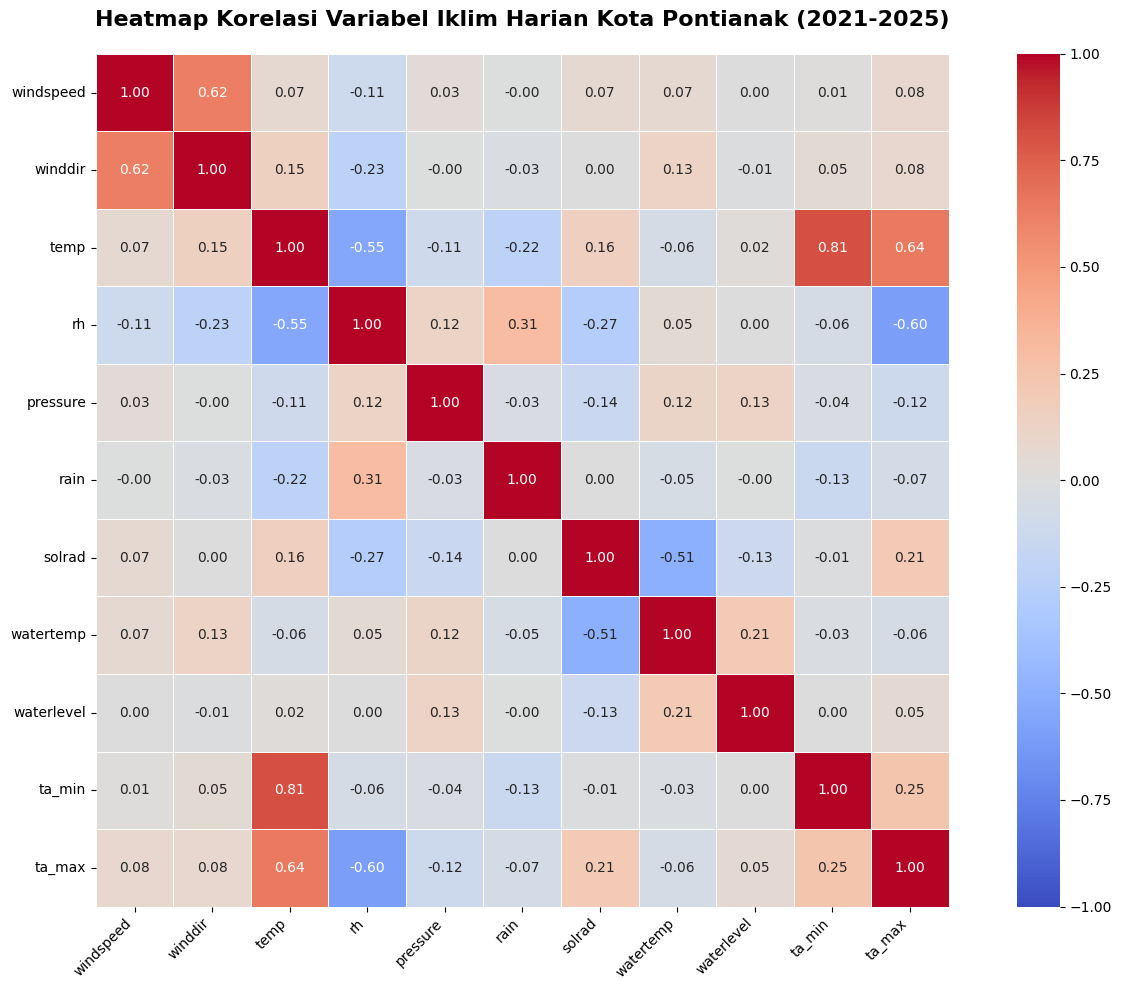


--- SELEKSI VARIABEL (MULTIKOLINEARITAS) ---
[INFO] Pasangan variabel dengan korelasi tinggi (|r| > 0.8):
 -> temp & ta_min : 0.807


In [ ]:
# ==========================================
# 1. IMPORT LIBRARY & HUBUNGKAN GOOGLE DRIVE
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# Menghubungkan Google Colab dengan Google Drive
drive.mount('/content/drive')

# Setup path folder dan nama file
folder_path = '/content/drive/MyDrive/dataset'
file_name = 'final_full_dataset'

# Cek ekstensi file (csv atau xlsx) dan muat data
file_csv = os.path.join(folder_path, f'{file_name}.csv')
file_xlsx = os.path.join(folder_path, f'{file_name}.xlsx')

print("\n--- PROSES LOADING DATA ---")
if os.path.exists(file_csv):
    print("Ditemukan file CSV. Membaca data...")
    df = pd.read_csv(file_csv)
elif os.path.exists(file_xlsx):
    print("Ditemukan file Excel (XLSX). Membaca data...")
    df = pd.read_excel(file_xlsx)
else:
    raise FileNotFoundError("File tidak ditemukan! Pastikan path 'dataset/final_full_dataset' sudah benar di Google Drive.")

# Menampilkan informasi dasar dataset
print("\n[INFO] 5 Baris Teratas Dataset:")
display(df.head())

print(f"\n[INFO] Dimensi Dataset (Baris, Kolom): {df.shape}")

print("\n[INFO] Informasi Detail Dataset:")
df.info()


# ==========================================
# 2. PRAPROSES AWAL (MISSING VALUE & NUMERIK)
# ==========================================
print("\n--- PRAPROSES AWAL ---")
# Cek Missing Value
missing_values = df.isnull().sum()
print("[INFO] Jumlah Missing Value per Kolom:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Tidak ada missing value (Data Bersih).")

# Mengabaikan kolom waktu dan mengambil hanya kolom numerik
if 'waktu' in df.columns:
    df_numeric = df.drop(columns=['waktu']).select_dtypes(include=[np.number])
else:
    df_numeric = df.select_dtypes(include=[np.number])

# [PENTING] Membuang kolom yang nilainya konstan (misal: pancilevel selalu 0)
# Kolom konstan akan menghasilkan nilai NaN pada korelasi Pearson
df_numeric = df_numeric.loc[:, df_numeric.std() > 0]

print(f"\n[INFO] Kolom numerik yang akan dianalisis ({len(df_numeric.columns)} kolom):")
print(df_numeric.columns.tolist())


# ==========================================
# 3. ANALISIS KORELASI PEARSON & HEATMAP
# ==========================================
print("\n--- ANALISIS KORELASI PEARSON ---")
# Menghitung matriks korelasi
corr_matrix = df_numeric.corr(method='pearson')

# Menampilkan tabel matriks korelasi
print("[INFO] Tabel Matriks Korelasi:")
display(corr_matrix.round(3))

# Visualisasi Heatmap Korelasi
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True,          # Menampilkan angka korelasi
            cmap='coolwarm',     # Skema warna (biru negatif, merah positif)
            fmt=".2f",           # Format 2 angka di belakang koma
            vmin=-1, vmax=1,     # Batas nilai korelasi
            linewidths=0.5,      # Garis antar kotak
            square=True,
            annot_kws={"size": 10}) # Ukuran font angka
plt.title('Heatmap Korelasi Variabel Iklim Harian Kota Pontianak (2021-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# ==========================================
# 4. SELEKSI VARIABEL (MULTIKOLINEARITAS)
# ==========================================
print("\n--- SELEKSI VARIABEL (MULTIKOLINEARITAS) ---")
threshold = 0.80  # Batas korelasi tinggi (|r| > 0.8)
high_corr_pairs =[]

# Mengambil segitiga atas dari matriks korelasi untuk menghindari duplikasi pasangan
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

for col in upper_tri.columns:
    for row in upper_tri.index:
        val = upper_tri.loc[row, col]
        if abs(val) > threshold:
            high_corr_pairs.append((row, col, val))

print(f"[INFO] Pasangan variabel dengan korelasi tinggi (|r| > {threshold}):")
if not high_corr_pairs:
    print("Tidak ditemukan pasangan dengan korelasi > 0.80.")
else:
    for pair in high_corr_pairs:
        print(f" -> {pair[0]} & {pair[1]} : {pair[2]:.3f}")

In [ ]:
# ==========================================
# IMPORT LIBRARY YANG DIBUTUHKAN
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

# Mengabaikan warning agar output skripsi terlihat rapi
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD DATA & HUBUNGKAN GOOGLE DRIVE
# ==========================================
print("==========================================")
print("1. PROSES LOADING DATA")
print("==========================================\n")

drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/dataset'
file_name = 'fix_final_dataset'

file_csv = os.path.join(folder_path, f'{file_name}.csv')
file_xlsx = os.path.join(folder_path, f'{file_name}.xlsx')

if os.path.exists(file_csv):
    df = pd.read_csv(file_csv)
    print("-> Berhasil memuat file CSV.")
elif os.path.exists(file_xlsx):
    df = pd.read_excel(file_xlsx)
    print("-> Berhasil memuat file Excel.")
else:
    raise FileNotFoundError("File tidak ditemukan! Pastikan path benar di Google Drive.")

print("\n[INFO] 5 Baris Teratas Dataset:")
display(df.head())

print(f"\n[INFO] Dimensi Dataset: {df.shape[0]} Baris, {df.shape[1]} Kolom")
print("\n[INFO] Informasi Tipe Data:")
df.info()


# ==========================================
# 2 & 3. PERSIAPAN DATA & PENANGANAN MISSING VALUE
# ==========================================
print("\n==========================================")
print("2 & 3. PERSIAPAN & IMPUTASI MISSING VALUE")
print("==========================================\n")

# Konversi kolom waktu menjadi datetime
if 'waktu' in df.columns:
    df['waktu'] = pd.to_datetime(df['waktu'])
    df = df.sort_values(by='waktu').reset_index(drop=True)

features =['windspeed', 'temp', 'rh', 'pressure', 'rain', 'ta_max', 'ta_min']

# Cek Missing Value Sebelum Imputasi
print("[INFO] Jumlah Missing Value SEBELUM Imputasi:")
missing_before = df[features].isnull().sum()
print(missing_before)

if missing_before.sum() > 0:
    print("\n-> Melakukan Imputasi Interpolasi Linier untuk data time series harian...")
    # 1. Interpolasi Linier
    df[features] = df[features].interpolate(method='linear')
    # 2. Forward Fill & Backward Fill (jika ada NaN di indeks pertama/terakhir)
    df[features] = df[features].bfill().ffill()

    print("\n[INFO] Jumlah Missing Value SESUDAH Imputasi:")
    print(df[features].isnull().sum())
else:
    print("\n-> Data bersih, tidak ditemukan missing value.")

# Ekstraksi fitur numerik untuk clustering
X = df[features].copy()


# ==========================================
# 4. NORMALISASI DATA (MIN-MAX SCALER)
# ==========================================
print("\n==========================================")
print("4. NORMALISASI DATA")
print("==========================================\n")

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=features)
print("[INFO] 5 Baris Data Setelah Min-Max Normalization (Skala 0 - 1):")
display(df_scaled.head())


# ==========================================
# 5. PENENTUAN JUMLAH KLASTER OPTIMAL (K-MEANS)
# ==========================================
print("\n==========================================")
print("5. UJI JUMLAH KLASTER K-MEANS")
print("==========================================\n")

wcss = []
silhouette_scores_kmeans =[]
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Gabungan Elbow & Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Jumlah Klaster (k)', fontsize=12)
ax1.set_ylabel('WCSS (Inertia)', color=color, fontsize=12)
ax1.plot(K_range, wcss, marker='o', color=color, linewidth=2, label='WCSS (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(K_range)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
ax2.plot(K_range, silhouette_scores_kmeans, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi Jumlah Klaster K-Means (Elbow vs Silhouette)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

best_k_kmeans = K_range[np.argmax(silhouette_scores_kmeans)]
print(f"=> Berdasarkan nilai Silhouette Score tertinggi, jumlah klaster K-Means optimal adalah K = {best_k_kmeans}")


# ==========================================
# 6. PENENTUAN JUMLAH KLASTER (HIERARCHICAL)
# ==========================================
print("\n==========================================")
print("6. PENENTUAN KLASTER HIERARCHICAL (DENDROGRAM)")
print("==========================================\n")

# Membuat Linkage Matrix (Ward Method)
linkage_matrix = sch.linkage(X_scaled, method='ward', metric='euclidean')

# Menghitung lonjakan jarak terbesar untuk menentukan K otomatis
distances = linkage_matrix[:, 2]
jumps =[]
k_hc_range = list(range(2, 11))

for k in k_hc_range:
    jump = distances[-k+1] - distances[-k] # Jarak lonjakan vertikal
    jumps.append(jump)

best_k_hc = k_hc_range[np.argmax(jumps)]
cut_distance = distances[-best_k_hc] # Jarak potong untuk plotting

plt.figure(figsize=(14, 6))
plt.title('Dendrogram Hierarchical Clustering (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Indeks Data Harian', fontsize=12)
plt.ylabel('Jarak Euclidean', fontsize=12)

dendrogram = sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.axhline(y=cut_distance, color='r', linestyle='--', linewidth=2, label=f'Garis Potong (k={best_k_hc})')

plt.legend()
plt.show()

print(f"=> Berdasarkan lonjakan jarak vertikal terbesar pada dendrogram, klaster Hierarchical optimal adalah K = {best_k_hc}")


# ==========================================
# 7. IMPLEMENTASI MODEL FINAL
# ==========================================
print("\n==========================================")
print("7. IMPLEMENTASI CLUSTERING FINAL")
print("==========================================\n")

# K-MEANS FINAL
kmeans_final = KMeans(n_clusters=best_k_kmeans, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

# HIERARCHICAL FINAL
hc_final = AgglomerativeClustering(n_clusters=best_k_hc, metric='euclidean', linkage='ward')
hc_labels = hc_final.fit_predict(X_scaled)
df['HC_Cluster'] = hc_labels

print("-> Model berhasil dieksekusi. Label masing-masing metode telah ditambahkan ke dataset.")


# ==========================================
# 8. VISUALISASI HASIL (PCA 2D)
# ==========================================
print("\n==========================================")
print("8. VISUALISASI HASIL CLUSTERING (PCA 2D)")
print("==========================================\n")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', data=df, palette='Set1', ax=ax1, s=50, alpha=0.8)
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='black', label='Centroid')
ax1.set_title(f'K-Means Clustering (k={best_k_kmeans})', fontsize=14, fontweight='bold')
ax1.legend()

# Plot Hierarchical
sns.scatterplot(x='PCA1', y='PCA2', hue='HC_Cluster', data=df, palette='Set1', ax=ax2, s=50, alpha=0.8)
ax2.set_title(f'Hierarchical Clustering (k={best_k_hc})', fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()


# ==========================================
# 9. EVALUASI DAN KOMPARASI KEDUA METODE
# ==========================================
print("\n==========================================")
print("9. EVALUASI & KOMPARASI KINERJA MODEL")
print("==========================================\n")

eval_data = {
    'Metode':[f'K-Means (k={best_k_kmeans})', f'Hierarchical (k={best_k_hc})'],
    'Silhouette Score (↑)':[
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, hc_labels)
    ],
    'Davies-Bouldin Index (↓)':[
        davies_bouldin_score(X_scaled, kmeans_labels),
        davies_bouldin_score(X_scaled, hc_labels)
    ],
    'Calinski-Harabasz Index (↑)':[
        calinski_harabasz_score(X_scaled, kmeans_labels),
        calinski_harabasz_score(X_scaled, hc_labels)
    ]
}

df_eval = pd.DataFrame(eval_data)
display(df_eval.round(4))

print("\nKeterangan Metrik:")
print("- Silhouette Score: Kedekatan intra-cluster & kejauhan antar-cluster (Semakin TINGGI mendekati 1 semakin baik).")
print("- Davies-Bouldin Index (DBI): Rasio sebaran klaster terhadap jarak pemisahnya (Semakin RENDAH mendekati 0 semakin baik).")
print("- Calinski-Harabasz Index (CHI): Varian antar klaster dibagi varian intra-klaster (Semakin TINGGI semakin padat dan baik).")


# ==========================================
# 10. INTERPRETASI KLASTER (PROFILING CUACA)
# ==========================================
print("\n==========================================")
print("10. PROFILING & INTERPRETASI KLASTER")
print("==========================================\n")

print(f"--- Profil Karakteristik Klaster K-MEANS (Nilai Asli Rata-rata) ---")
kmeans_profile = df.groupby('KMeans_Cluster')[features].mean()
display(kmeans_profile.round(2))

print(f"\n--- Profil Karakteristik Klaster HIERARCHICAL (Nilai Asli Rata-rata) ---")
hc_profile = df.groupby('HC_Cluster')[features].mean()
display(hc_profile.round(2))


# ==========================================
# 11. OUTPUT AKHIR
# ==========================================
print("\n==========================================")
print("11. KESIMPULAN & PENYIMPANAN DATA")
print("==========================================\n")

# Logika untuk mencari metode pemenang berdasarkan metrik
km_sil, hc_sil = eval_data['Silhouette Score (↑)']
km_dbi, hc_dbi = eval_data['Davies-Bouldin Index (↓)']

if km_sil > hc_sil and km_dbi < hc_dbi:
    best_method = "K-Means Clustering"
elif hc_sil > km_sil and hc_dbi < km_dbi:
    best_method = "Hierarchical Clustering"
else:
    best_method = "Kedua metode memiliki keunggulan pada metrik yang berbeda (Lihat tabel untuk detail)"

print(f"KESIMPULAN METODE TERBAIK:")
print(f"Berdasarkan evaluasi metrik validasi, disimpulkan bahwa {best_method} lebih optimal untuk mengelompokkan data cuaca harian Kota Pontianak ini.")

# Menghapus kolom sementara (PCA) untuk CSV final
df_final_export = df.drop(columns=['PCA1', 'PCA2'])

output_path = os.path.join(folder_path, 'hasil_clustering_komparasi_final.csv')
df_final_export.to_csv(output_path, index=False)

print(f"\n[SUKSES] Dataset hasil clustering beserta label klaster telah disimpan ke:")
print(f"-> {output_path}")

1. PROSES LOADING DATA

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-> Berhasil memuat file Excel.

[INFO] 5 Baris Teratas Dataset:


,waktu,windspeed,temp,rh,pressure,rain,ta_max,solrad
0,2021-01-01,1.220112,27.322845,83.693693,1007.480168,0.0,32.7,103.18840
1,2021-01-02,0.849470,27.050530,85.494621,1007.633939,0.0,30.9,76.56659
2,2021-01-03,1.080733,27.488571,83.911136,1007.799927,0.0,30.9,59.63473
3,2021-01-04,1.297462,26.723077,86.041077,1008.119154,0.0,32.6,96.05785
4,2021-01-05,1.107137,27.574213,81.913124,1007.452801,0.0,31.2,81.80952



[INFO] Dimensi Dataset: 1795 Baris, 8 Kolom

[INFO] Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   waktu      1795 non-null   datetime64[ns]
 1   windspeed  1783 non-null   float64       
 2   temp       1783 non-null   float64       
 3   rh         1783 non-null   float64       
 4   pressure   1783 non-null   float64       
 5   rain       1795 non-null   float64       
 6   ta_max     1783 non-null   float64       
 7   solrad     1783 non-null   float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 112.3 KB

2 & 3. PERSIAPAN & IMPUTASI MISSING VALUE

[INFO] Jumlah Missing Value SEBELUM Imputasi:


KeyError: "['ta_min'] not in index"

1. PROSES LOADING DATA

Mounted at /content/drive
-> Berhasil memuat file Excel.

[INFO] Dimensi Dataset: 1795 Baris, 9 Kolom

2 & 3. PERSIAPAN & IMPUTASI MISSING VALUE

-> Melakukan Imputasi Interpolasi Linier untuk data time series harian...

4. TRANSFORMASI & NORMALISASI DATA (STANDARD SCALER)



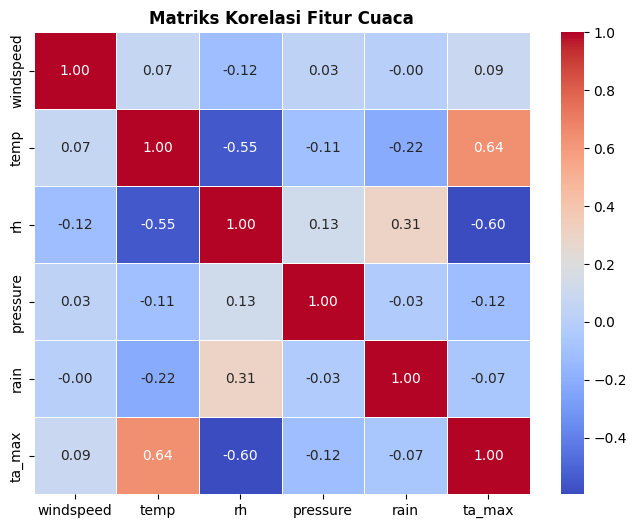

-> Catatan: Jika temp dan ta_max berkorelasi sangat tinggi (>0.85), PCA akan mengatasinya secara otomatis.

-> Transformasi Logaritmik (log1p) diterapkan pada fitur 'rain'.
-> Normalisasi menggunakan StandardScaler selesai.

4.5 REDUKSI DIMENSI (PCA) SEBELUM CLUSTERING

-> PCA berhasil mereduksi dari 6 fitur menjadi 5 komponen utama (Principal Components).
-> Komponen ini mempertahankan 95.40% informasi asli.

5. UJI JUMLAH KLASTER K-MEANS (PADA DATA PCA)



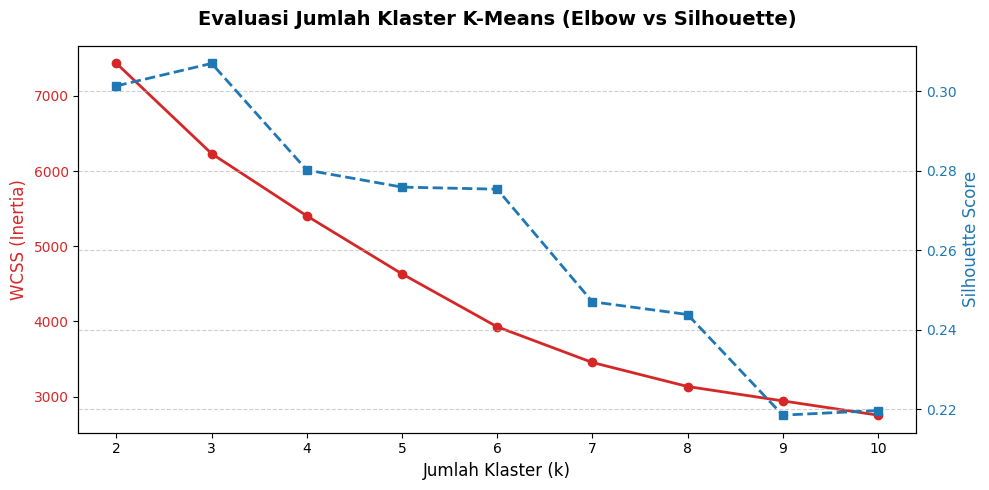

=> Berdasarkan nilai Silhouette Score tertinggi, jumlah klaster K-Means optimal adalah K = 3

6. PENENTUAN KLASTER HIERARCHICAL (DENDROGRAM)



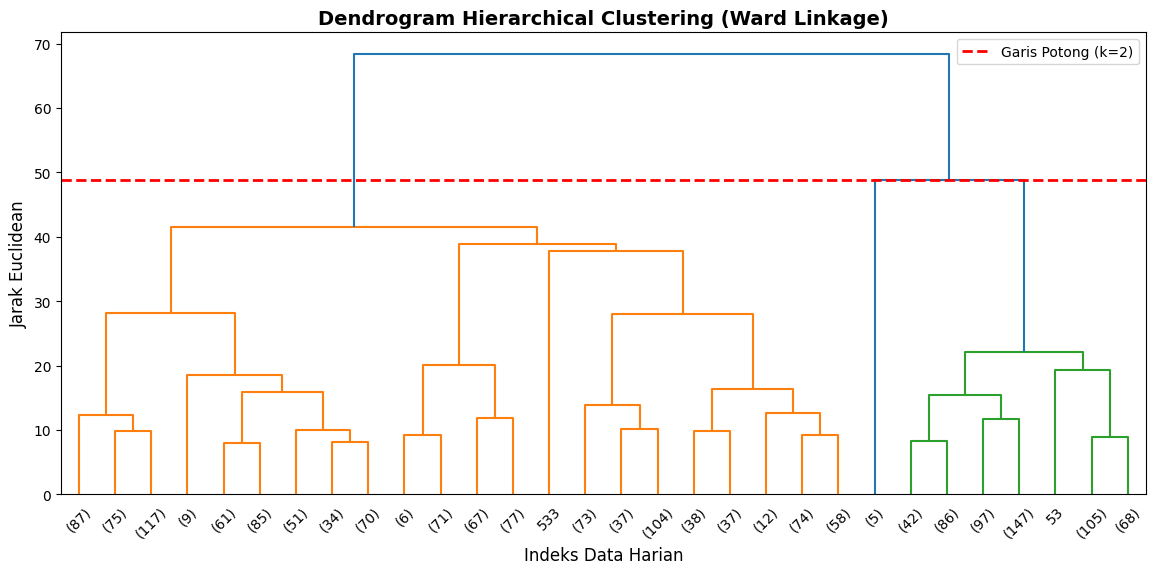

=> Berdasarkan lonjakan jarak vertikal terbesar, klaster Hierarchical optimal adalah K = 2

7. IMPLEMENTASI CLUSTERING FINAL

-> Model berhasil dieksekusi pada ruang PCA. Label telah ditambahkan ke dataset asli.

8. VISUALISASI HASIL CLUSTERING (PCA 2D)



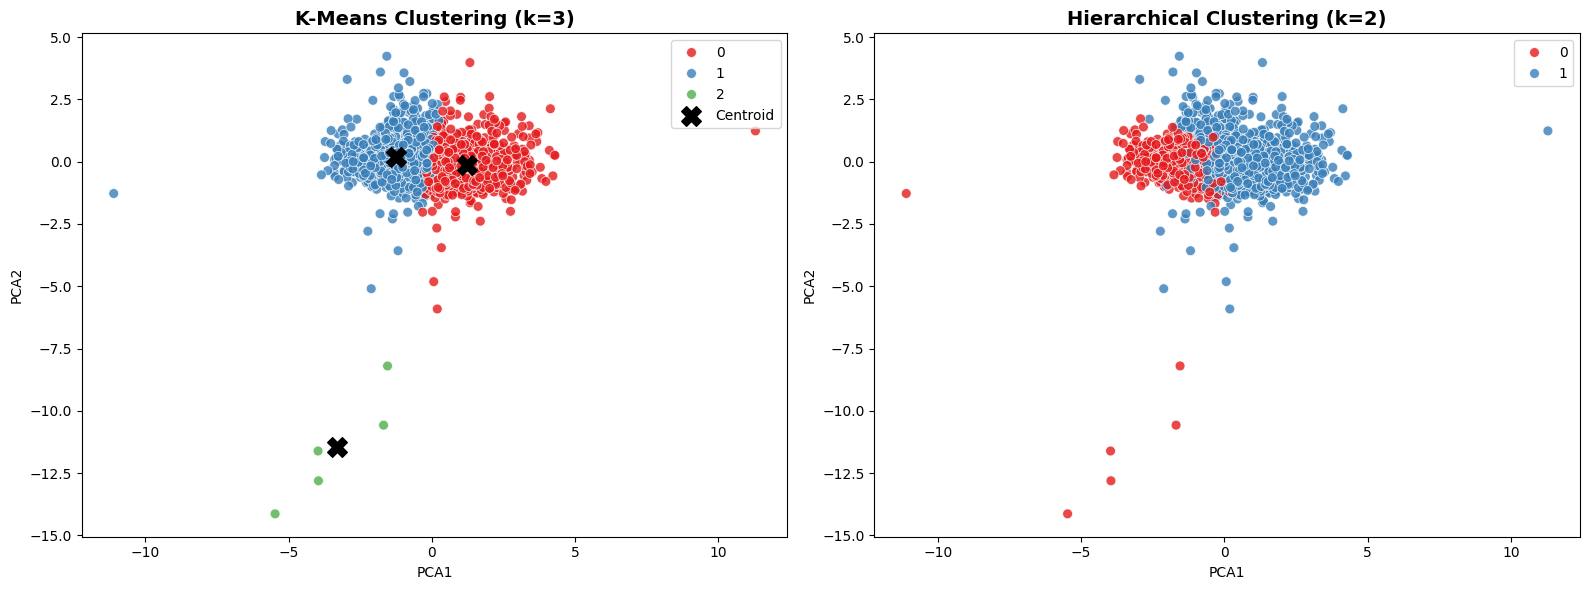


9. EVALUASI & KOMPARASI KINERJA MODEL



,Metode,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑)
0,K-Means (k=3),0.3070,0.9355,581.1733
1,Hierarchical (k=2),0.2631,1.2889,527.2620



10. PROFILING & INTERPRETASI KLASTER

-> Catatan: Nilai di bawah ini adalah nilai ASLI (sebelum log & scaling) agar mudah diinterpretasi.

--- Profil Karakteristik Klaster K-MEANS ---


,windspeed,temp,rh,pressure,rain,ta_max
KMeans_Cluster,,,,,,
0,1.09,26.77,85.81,1008.46,15.55,31.18
1,1.20,28.70,76.85,1008.06,2.61,33.32
2,1.07,28.86,75.26,956.67,11.44,33.84



--- Profil Karakteristik Klaster HIERARCHICAL ---


,windspeed,temp,rh,pressure,rain,ta_max
HC_Cluster,,,,,,
0,1.09,29.07,75.35,1007.56,1.49,33.83
1,1.17,27.13,84.08,1008.37,12.62,31.53



11. PENYIMPANAN DATA

[SUKSES] Dataset hasil clustering (Versi Optimasi) telah disimpan ke:
-> /content/drive/MyDrive/dataset/hasil_clustering_komparasi_final_Optimized.csv


In [ ]:
# ==========================================
# IMPORT LIBRARY YANG DIBUTUHKAN
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from google.colab import drive
from sklearn.preprocessing import StandardScaler # Diubah dari MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

# Mengabaikan warning agar output skripsi terlihat rapi
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD DATA & HUBUNGKAN GOOGLE DRIVE
# ==========================================
print("==========================================")
print("1. PROSES LOADING DATA")
print("==========================================\n")

drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/dataset'
file_name = 'fix_final_dataset'

file_csv = os.path.join(folder_path, f'{file_name}.csv')
file_xlsx = os.path.join(folder_path, f'{file_name}.xlsx')

if os.path.exists(file_csv):
    df = pd.read_csv(file_csv)
    print("-> Berhasil memuat file CSV.")
elif os.path.exists(file_xlsx):
    df = pd.read_excel(file_xlsx)
    print("-> Berhasil memuat file Excel.")
else:
    raise FileNotFoundError("File tidak ditemukan! Pastikan path benar di Google Drive.")

print(f"\n[INFO] Dimensi Dataset: {df.shape[0]} Baris, {df.shape[1]} Kolom")

# ==========================================
# 2 & 3. PERSIAPAN DATA & PENANGANAN MISSING VALUE
# ==========================================
print("\n==========================================")
print("2 & 3. PERSIAPAN & IMPUTASI MISSING VALUE")
print("==========================================\n")

if 'waktu' in df.columns:
    df['waktu'] = pd.to_datetime(df['waktu'])
    df = df.sort_values(by='waktu').reset_index(drop=True)

features =['windspeed', 'temp', 'rh', 'pressure', 'rain', 'ta_max']

missing_before = df[features].isnull().sum()
if missing_before.sum() > 0:
    print("-> Melakukan Imputasi Interpolasi Linier untuk data time series harian...")
    df[features] = df[features].interpolate(method='linear').bfill().ffill()
else:
    print("-> Data bersih, tidak ditemukan missing value.")

# ==========================================
# 4. FEATURE ENGINEERING & NORMALISASI (OPTIMASI)
# ==========================================
print("\n==========================================")
print("4. TRANSFORMASI & NORMALISASI DATA (STANDARD SCALER)")
print("==========================================\n")

X = df[features].copy()

# A. Cek Korelasi (Visualisasi Opsional untuk Analisis)
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi Fitur Cuaca", fontweight='bold')
plt.show()
print("-> Catatan: Jika temp dan ta_max berkorelasi sangat tinggi (>0.85), PCA akan mengatasinya secara otomatis.\n")

# B. Transformasi Logaritmik untuk Curah Hujan (Mengatasi Skewness/Outlier)
# Menggunakan log1p (log(1 + x)) karena curah hujan bisa bernilai 0
X['rain'] = np.log1p(X['rain'])
print("-> Transformasi Logaritmik (log1p) diterapkan pada fitur 'rain'.")

# C. Normalisasi menggunakan StandardScaler (Z-Score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("-> Normalisasi menggunakan StandardScaler selesai.")

# ==========================================
# 4.5 REDUKSI DIMENSI DENGAN PCA (OPTIMASI)
# ==========================================
print("\n==========================================")
print("4.5 REDUKSI DIMENSI (PCA) SEBELUM CLUSTERING")
print("==========================================\n")

# Menggunakan PCA untuk mempertahankan 95% variansi data (membuang noise)
pca_model = PCA(n_components=0.95, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)

n_pca_components = X_pca.shape[1]
print(f"-> PCA berhasil mereduksi dari {len(features)} fitur menjadi {n_pca_components} komponen utama (Principal Components).")
print(f"-> Komponen ini mempertahankan {sum(pca_model.explained_variance_ratio_)*100:.2f}% informasi asli.")

# ==========================================
# 5. PENENTUAN JUMLAH KLASTER OPTIMAL (K-MEANS)
# ==========================================
print("\n==========================================")
print("5. UJI JUMLAH KLASTER K-MEANS (PADA DATA PCA)")
print("==========================================\n")

wcss = []
silhouette_scores_kmeans =[]
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca) # Clustering dilakukan pada data PCA
    wcss.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_pca, kmeans.labels_))

# Plot Gabungan Elbow & Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:red'
ax1.set_xlabel('Jumlah Klaster (k)', fontsize=12)
ax1.set_ylabel('WCSS (Inertia)', color=color, fontsize=12)
ax1.plot(K_range, wcss, marker='o', color=color, linewidth=2, label='WCSS (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(K_range)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
ax2.plot(K_range, silhouette_scores_kmeans, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi Jumlah Klaster K-Means (Elbow vs Silhouette)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

best_k_kmeans = K_range[np.argmax(silhouette_scores_kmeans)]
print(f"=> Berdasarkan nilai Silhouette Score tertinggi, jumlah klaster K-Means optimal adalah K = {best_k_kmeans}")

# ==========================================
# 6. PENENTUAN JUMLAH KLASTER (HIERARCHICAL)
# ==========================================
print("\n==========================================")
print("6. PENENTUAN KLASTER HIERARCHICAL (DENDROGRAM)")
print("==========================================\n")

linkage_matrix = sch.linkage(X_pca, method='ward', metric='euclidean')

distances = linkage_matrix[:, 2]
jumps =[]
k_hc_range = list(range(2, 11))

for k in k_hc_range:
    jump = distances[-k+1] - distances[-k]
    jumps.append(jump)

best_k_hc = k_hc_range[np.argmax(jumps)]
cut_distance = distances[-best_k_hc]

plt.figure(figsize=(14, 6))
plt.title('Dendrogram Hierarchical Clustering (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Indeks Data Harian', fontsize=12)
plt.ylabel('Jarak Euclidean', fontsize=12)
dendrogram = sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.axhline(y=cut_distance, color='r', linestyle='--', linewidth=2, label=f'Garis Potong (k={best_k_hc})')
plt.legend()
plt.show()

print(f"=> Berdasarkan lonjakan jarak vertikal terbesar, klaster Hierarchical optimal adalah K = {best_k_hc}")

# ==========================================
# 7. IMPLEMENTASI MODEL FINAL
# ==========================================
print("\n==========================================")
print("7. IMPLEMENTASI CLUSTERING FINAL")
print("==========================================\n")

# K-MEANS FINAL
kmeans_final = KMeans(n_clusters=best_k_kmeans, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca)
df['KMeans_Cluster'] = kmeans_labels

# HIERARCHICAL FINAL
hc_final = AgglomerativeClustering(n_clusters=best_k_hc, metric='euclidean', linkage='ward')
hc_labels = hc_final.fit_predict(X_pca)
df['HC_Cluster'] = hc_labels

print("-> Model berhasil dieksekusi pada ruang PCA. Label telah ditambahkan ke dataset asli.")

# ==========================================
# 8. VISUALISASI HASIL (PCA 2D)
# ==========================================
print("\n==========================================")
print("8. VISUALISASI HASIL CLUSTERING (PCA 2D)")
print("==========================================\n")

# Mengambil 2 komponen pertama untuk visualisasi 2D
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', data=df, palette='Set1', ax=ax1, s=50, alpha=0.8)
centroids_pca = kmeans_final.cluster_centers_
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='black', label='Centroid')
ax1.set_title(f'K-Means Clustering (k={best_k_kmeans})', fontsize=14, fontweight='bold')
ax1.legend()

# Plot Hierarchical
sns.scatterplot(x='PCA1', y='PCA2', hue='HC_Cluster', data=df, palette='Set1', ax=ax2, s=50, alpha=0.8)
ax2.set_title(f'Hierarchical Clustering (k={best_k_hc})', fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 9. EVALUASI DAN KOMPARASI KEDUA METODE
# ==========================================
print("\n==========================================")
print("9. EVALUASI & KOMPARASI KINERJA MODEL")
print("==========================================\n")

eval_data = {
    'Metode':[f'K-Means (k={best_k_kmeans})', f'Hierarchical (k={best_k_hc})'],
    'Silhouette Score (↑)':[
        silhouette_score(X_pca, kmeans_labels),
        silhouette_score(X_pca, hc_labels)
    ],
    'Davies-Bouldin Index (↓)':[
        davies_bouldin_score(X_pca, kmeans_labels),
        davies_bouldin_score(X_pca, hc_labels)
    ],
    'Calinski-Harabasz Index (↑)':[
        calinski_harabasz_score(X_pca, kmeans_labels),
        calinski_harabasz_score(X_pca, hc_labels)
    ]
}

df_eval = pd.DataFrame(eval_data)
display(df_eval.round(4))

# ==========================================
# 10. INTERPRETASI KLASTER (PROFILING CUACA)
# ==========================================
print("\n==========================================")
print("10. PROFILING & INTERPRETASI KLASTER")
print("==========================================\n")

print("-> Catatan: Nilai di bawah ini adalah nilai ASLI (sebelum log & scaling) agar mudah diinterpretasi.")

print(f"\n--- Profil Karakteristik Klaster K-MEANS ---")
kmeans_profile = df.groupby('KMeans_Cluster')[features].mean()
display(kmeans_profile.round(2))

print(f"\n--- Profil Karakteristik Klaster HIERARCHICAL ---")
hc_profile = df.groupby('HC_Cluster')[features].mean()
display(hc_profile.round(2))

# ==========================================
# 11. OUTPUT AKHIR
# ==========================================
print("\n==========================================")
print("11. PENYIMPANAN DATA")
print("==========================================\n")

df_final_export = df.drop(columns=['PCA1', 'PCA2'])
output_path = os.path.join(folder_path, 'hasil_clustering_komparasi_final_Optimized.csv')
df_final_export.to_csv(output_path, index=False)

print(f"[SUKSES] Dataset hasil clustering (Versi Optimasi) telah disimpan ke:")
print(f"-> {output_path}")

1. PROSES LOADING DATA

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-> Berhasil memuat file Excel.

[INFO] Dimensi Dataset: 1795 Baris, 15 Kolom

2. PEMILIHAN FITUR & IMPUTASI MISSING VALUE

-> Melakukan Imputasi Interpolasi Linier untuk data time series harian...

3. TRANSFORMASI LOG & NORMALISASI (MIN-MAX SCALER)

-> Transformasi Logaritmik (log1p) diterapkan pada fitur 'rain'.
-> Normalisasi menggunakan MinMaxScaler selesai.

4. REDUKSI DIMENSI (PCA) SEBELUM CLUSTERING

-> PCA berhasil mereduksi dari 7 fitur menjadi 4 komponen utama.
-> Komponen ini mempertahankan 97.14% informasi asli.

5. UJI JUMLAH KLASTER K-MEANS (PADA DATA PCA)



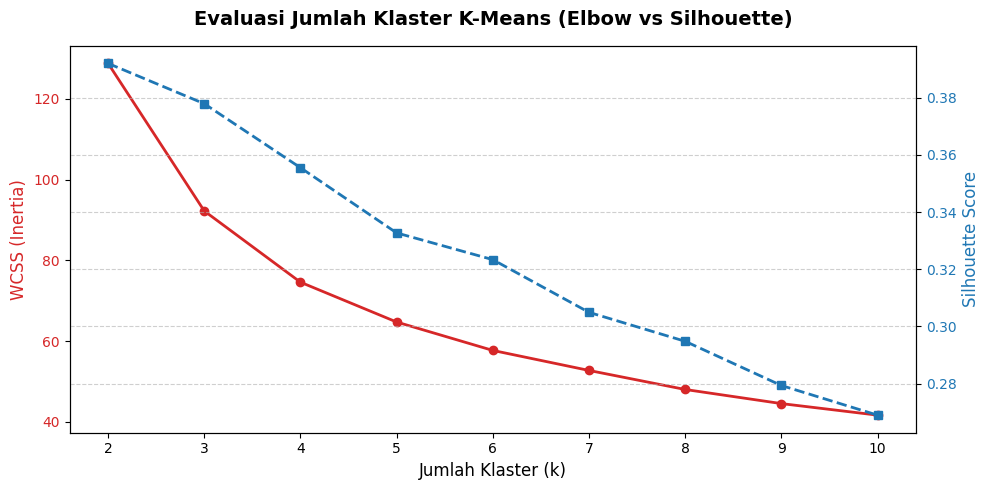

=> Berdasarkan nilai Silhouette Score tertinggi, jumlah klaster K-Means optimal adalah K = 2

6. PENENTUAN KLASTER HIERARCHICAL (DENDROGRAM)



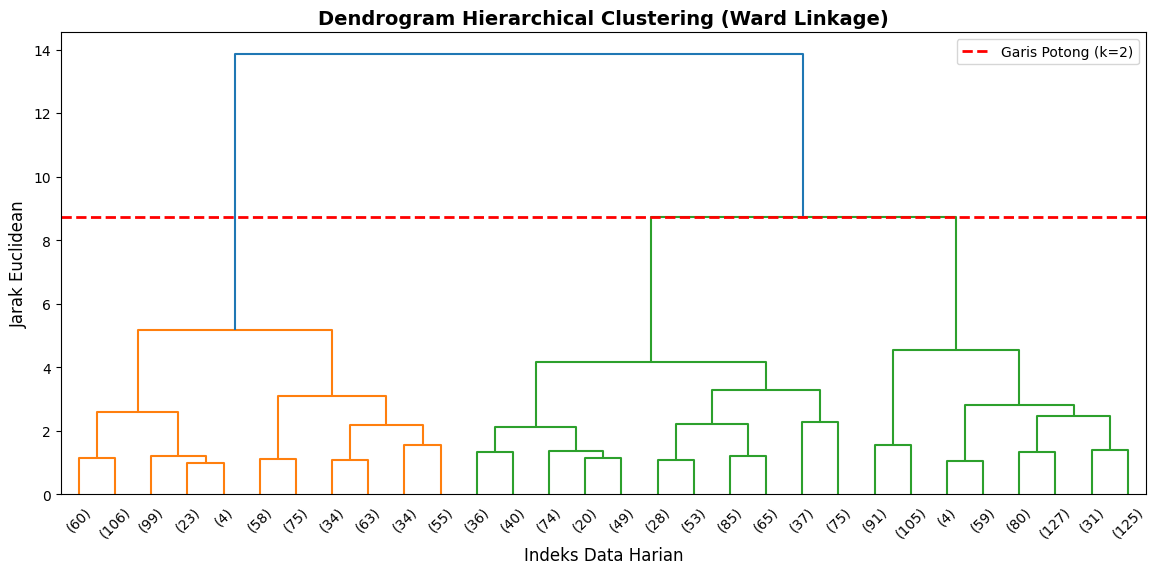

=> Berdasarkan lonjakan jarak vertikal terbesar, klaster Hierarchical optimal adalah K = 2

7. IMPLEMENTASI CLUSTERING FINAL

-> Model berhasil dieksekusi. Label telah ditambahkan ke dataset asli.

8. VISUALISASI HASIL CLUSTERING (PCA 2D)



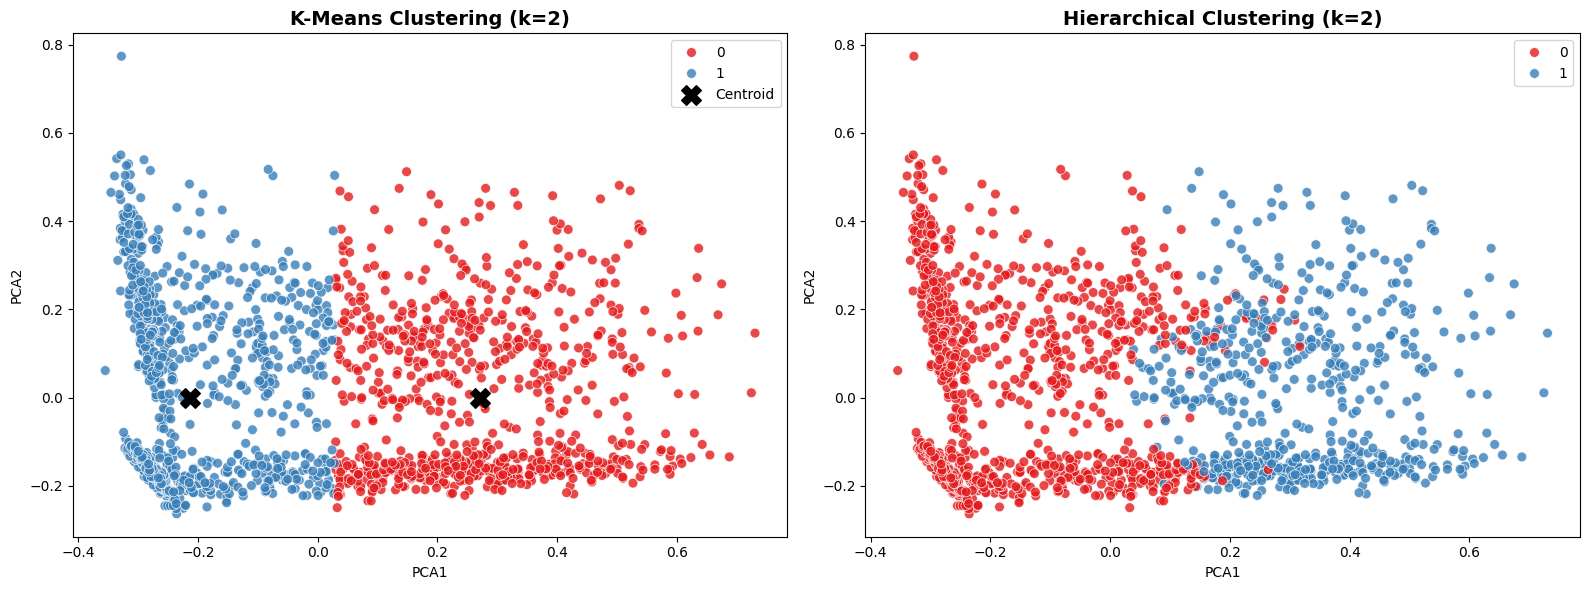


9. EVALUASI & KOMPARASI KINERJA MODEL



,Metode,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑)
0,K-Means (k=2),0.3919,1.0403,1451.5165
1,Hierarchical (k=2),0.3645,1.0416,1252.9530



10. PROFILING & INTERPRETASI KLASTER

-> Catatan: Nilai di bawah ini adalah nilai ASLI (sebelum log & scaling) agar mudah diinterpretasi.

--- Profil Karakteristik Klaster K-MEANS ---


,windspeed,temp,rh,pressure,rain,solrad,ta_max
KMeans_Cluster,,,,,,,
0,1.12,27.18,84.39,1008.22,20.13,69.83,31.90
1,1.16,28.15,79.04,1008.04,0.60,76.65,32.49



--- Profil Karakteristik Klaster HIERARCHICAL ---


,windspeed,temp,rh,pressure,rain,solrad,ta_max
HC_Cluster,,,,,,,
0,1.18,28.05,79.61,1008.08,1.45,76.11,32.43
1,1.09,27.09,84.86,1008.20,24.24,68.86,31.85



11. PENYIMPANAN DATA

[SUKSES] Dataset hasil clustering telah disimpan ke:
-> /content/drive/MyDrive/dataset/hasil_clustering_final_terbaik.csv


In [ ]:
# ==========================================
# IMPORT LIBRARY YANG DIBUTUHKAN
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

# Mengabaikan warning agar output skripsi terlihat rapi
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD DATA & HUBUNGKAN GOOGLE DRIVE
# ==========================================
print("==========================================")
print("1. PROSES LOADING DATA")
print("==========================================\n")

drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/dataset'
file_name = 'final_full_dataset' # Sesuaikan dengan nama file terbarumu

file_csv = os.path.join(folder_path, f'{file_name}.csv')
file_xlsx = os.path.join(folder_path, f'{file_name}.xlsx')

if os.path.exists(file_csv):
    df = pd.read_csv(file_csv)
    print("-> Berhasil memuat file CSV.")
elif os.path.exists(file_xlsx):
    df = pd.read_excel(file_xlsx)
    print("-> Berhasil memuat file Excel.")
else:
    raise FileNotFoundError("File tidak ditemukan! Pastikan path benar di Google Drive.")

print(f"\n[INFO] Dimensi Dataset: {df.shape[0]} Baris, {df.shape[1]} Kolom")

# ==========================================
# 2. PEMILIHAN FITUR & PENANGANAN MISSING VALUE
# ==========================================
print("\n==========================================")
print("2. PEMILIHAN FITUR & IMPUTASI MISSING VALUE")
print("==========================================\n")

if 'waktu' in df.columns:
    df['waktu'] = pd.to_datetime(df['waktu'])
    df = df.sort_values(by='waktu').reset_index(drop=True)

# Fitur final berdasarkan eksperimen dan uji korelasi
# ta_min dibuang (korelasi tinggi), winddir dibuang (data sirkular), variabel 0 dibuang
features =[
    'windspeed',
    'temp',
    'rh',
    'pressure',
    'rain',
    'solrad',     # Variabel tambahan yang terbukti menaikkan skor
    'ta_max'
]

# Cek dan tangani missing value
missing_before = df[features].isnull().sum()
if missing_before.sum() > 0:
    print("-> Melakukan Imputasi Interpolasi Linier untuk data time series harian...")
    df[features] = df[features].interpolate(method='linear').bfill().ffill()
else:
    print("-> Data bersih, tidak ditemukan missing value.")

# ==========================================
# 3. FEATURE ENGINEERING & NORMALISASI (MIN-MAX)
# ==========================================
print("\n==========================================")
print("3. TRANSFORMASI LOG & NORMALISASI (MIN-MAX SCALER)")
print("==========================================\n")

# Copy data agar df asli tidak berubah (untuk profiling nanti)
X = df[features].copy()

# Transformasi Logaritmik untuk Curah Hujan (Mengatasi Skewness/Outlier ekstrem)
X['rain'] = np.log1p(X['rain'])
print("-> Transformasi Logaritmik (log1p) diterapkan pada fitur 'rain'.")

# Normalisasi menggunakan MinMaxScaler (Terbukti empiris lebih baik untuk data ini)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
print("-> Normalisasi menggunakan MinMaxScaler selesai.")

# ==========================================
# 4. REDUKSI DIMENSI DENGAN PCA
# ==========================================
print("\n==========================================")
print("4. REDUKSI DIMENSI (PCA) SEBELUM CLUSTERING")
print("==========================================\n")

# Menggunakan PCA untuk mempertahankan 95% variansi data (membuang 5% noise)
pca_model = PCA(n_components=0.95, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)

n_pca_components = X_pca.shape[1]
print(f"-> PCA berhasil mereduksi dari {len(features)} fitur menjadi {n_pca_components} komponen utama.")
print(f"-> Komponen ini mempertahankan {sum(pca_model.explained_variance_ratio_)*100:.2f}% informasi asli.")

# ==========================================
# 5. PENENTUAN JUMLAH KLASTER OPTIMAL (K-MEANS)
# ==========================================
print("\n==========================================")
print("5. UJI JUMLAH KLASTER K-MEANS (PADA DATA PCA)")
print("==========================================\n")

wcss =[]
silhouette_scores_kmeans =[]
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_pca, kmeans.labels_))

# Plot Gabungan Elbow & Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:red'
ax1.set_xlabel('Jumlah Klaster (k)', fontsize=12)
ax1.set_ylabel('WCSS (Inertia)', color=color, fontsize=12)
ax1.plot(K_range, wcss, marker='o', color=color, linewidth=2, label='WCSS (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(K_range)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
ax2.plot(K_range, silhouette_scores_kmeans, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi Jumlah Klaster K-Means (Elbow vs Silhouette)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

best_k_kmeans = K_range[np.argmax(silhouette_scores_kmeans)]
print(f"=> Berdasarkan nilai Silhouette Score tertinggi, jumlah klaster K-Means optimal adalah K = {best_k_kmeans}")

# ==========================================
# 6. PENENTUAN JUMLAH KLASTER (HIERARCHICAL)
# ==========================================
print("\n==========================================")
print("6. PENENTUAN KLASTER HIERARCHICAL (DENDROGRAM)")
print("==========================================\n")

linkage_matrix = sch.linkage(X_pca, method='ward', metric='euclidean')

distances = linkage_matrix[:, 2]
jumps =[]
k_hc_range = list(range(2, 11))

for k in k_hc_range:
    jump = distances[-k+1] - distances[-k]
    jumps.append(jump)

best_k_hc = k_hc_range[np.argmax(jumps)]
cut_distance = distances[-best_k_hc]

plt.figure(figsize=(14, 6))
plt.title('Dendrogram Hierarchical Clustering (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Indeks Data Harian', fontsize=12)
plt.ylabel('Jarak Euclidean', fontsize=12)
dendrogram = sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.axhline(y=cut_distance, color='r', linestyle='--', linewidth=2, label=f'Garis Potong (k={best_k_hc})')
plt.legend()
plt.show()

print(f"=> Berdasarkan lonjakan jarak vertikal terbesar, klaster Hierarchical optimal adalah K = {best_k_hc}")

# ==========================================
# 7. IMPLEMENTASI MODEL FINAL
# ==========================================
print("\n==========================================")
print("7. IMPLEMENTASI CLUSTERING FINAL")
print("==========================================\n")

# K-MEANS FINAL
kmeans_final = KMeans(n_clusters=best_k_kmeans, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca)
df['KMeans_Cluster'] = kmeans_labels

# HIERARCHICAL FINAL
hc_final = AgglomerativeClustering(n_clusters=best_k_hc, metric='euclidean', linkage='ward')
hc_labels = hc_final.fit_predict(X_pca)
df['HC_Cluster'] = hc_labels

print("-> Model berhasil dieksekusi. Label telah ditambahkan ke dataset asli.")

# ==========================================
# 8. VISUALISASI HASIL (PCA 2D)
# ==========================================
print("\n==========================================")
print("8. VISUALISASI HASIL CLUSTERING (PCA 2D)")
print("==========================================\n")

# Mengambil 2 komponen pertama untuk visualisasi 2D
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', data=df, palette='Set1', ax=ax1, s=50, alpha=0.8)
centroids_pca = kmeans_final.cluster_centers_
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='black', label='Centroid')
ax1.set_title(f'K-Means Clustering (k={best_k_kmeans})', fontsize=14, fontweight='bold')
ax1.legend()

# Plot Hierarchical
sns.scatterplot(x='PCA1', y='PCA2', hue='HC_Cluster', data=df, palette='Set1', ax=ax2, s=50, alpha=0.8)
ax2.set_title(f'Hierarchical Clustering (k={best_k_hc})', fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 9. EVALUASI DAN KOMPARASI KEDUA METODE
# ==========================================
print("\n==========================================")
print("9. EVALUASI & KOMPARASI KINERJA MODEL")
print("==========================================\n")

eval_data = {
    'Metode':[f'K-Means (k={best_k_kmeans})', f'Hierarchical (k={best_k_hc})'],
    'Silhouette Score (↑)':[
        silhouette_score(X_pca, kmeans_labels),
        silhouette_score(X_pca, hc_labels)
    ],
    'Davies-Bouldin Index (↓)':[
        davies_bouldin_score(X_pca, kmeans_labels),
        davies_bouldin_score(X_pca, hc_labels)
    ],
    'Calinski-Harabasz Index (↑)':[
        calinski_harabasz_score(X_pca, kmeans_labels),
        calinski_harabasz_score(X_pca, hc_labels)
    ]
}

df_eval = pd.DataFrame(eval_data)
display(df_eval.round(4))

# ==========================================
# 10. INTERPRETASI KLASTER (PROFILING CUACA)
# ==========================================
print("\n==========================================")
print("10. PROFILING & INTERPRETASI KLASTER")
print("==========================================\n")

print("-> Catatan: Nilai di bawah ini adalah nilai ASLI (sebelum log & scaling) agar mudah diinterpretasi.")

print(f"\n--- Profil Karakteristik Klaster K-MEANS ---")
kmeans_profile = df.groupby('KMeans_Cluster')[features].mean()
display(kmeans_profile.round(2))

print(f"\n--- Profil Karakteristik Klaster HIERARCHICAL ---")
hc_profile = df.groupby('HC_Cluster')[features].mean()
display(hc_profile.round(2))

# ==========================================
# 11. OUTPUT AKHIR
# ==========================================
print("\n==========================================")
print("11. PENYIMPANAN DATA")
print("==========================================\n")

# Menghapus kolom PCA sementara sebelum disimpan
df_final_export = df.drop(columns=['PCA1', 'PCA2'])
output_path = os.path.join(folder_path, 'hasil_clustering_final_terbaik.csv')
df_final_export.to_csv(output_path, index=False)

print(f"[SUKSES] Dataset hasil clustering telah disimpan ke:")
print(f"-> {output_path}")

1. PROSES LOADING DATA

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-> Berhasil memuat file Excel.

[INFO] Dimensi Dataset: 1795 Baris, 15 Kolom

2. PEMILIHAN FITUR & IMPUTASI MISSING VALUE

-> Melakukan Imputasi Interpolasi Linier untuk data time series harian...

3. TRANSFORMASI LOG & NORMALISASI (MIN-MAX SCALER)

-> Transformasi Logaritmik (log1p) diterapkan pada fitur 'rain'.
-> Normalisasi menggunakan MinMaxScaler selesai.

4. REDUKSI DIMENSI (PCA) SEBELUM CLUSTERING

-> PCA berhasil mereduksi dari 6 fitur menjadi 3 komponen utama.
-> Komponen ini mempertahankan 96.04% informasi asli.

5. UJI JUMLAH KLASTER K-MEANS (PADA DATA PCA)



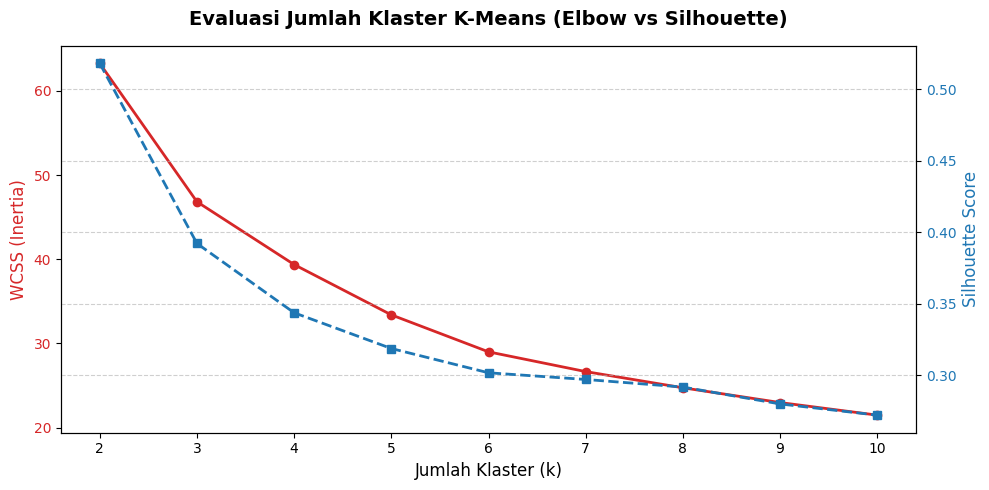

=> Berdasarkan nilai Silhouette Score tertinggi, jumlah klaster K-Means optimal adalah K = 2

6. PENENTUAN KLASTER HIERARCHICAL (DENDROGRAM)



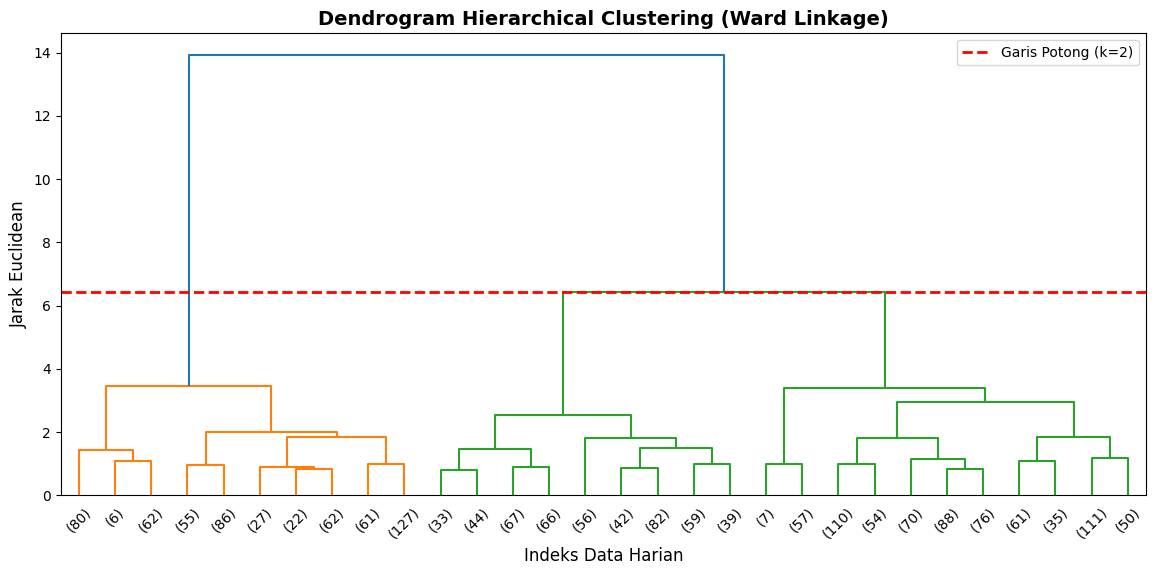

=> Berdasarkan lonjakan jarak vertikal terbesar, klaster Hierarchical optimal adalah K = 2

7. IMPLEMENTASI CLUSTERING FINAL

-> Model berhasil dieksekusi. Label telah ditambahkan ke dataset asli.

8. VISUALISASI HASIL CLUSTERING (PCA 2D)



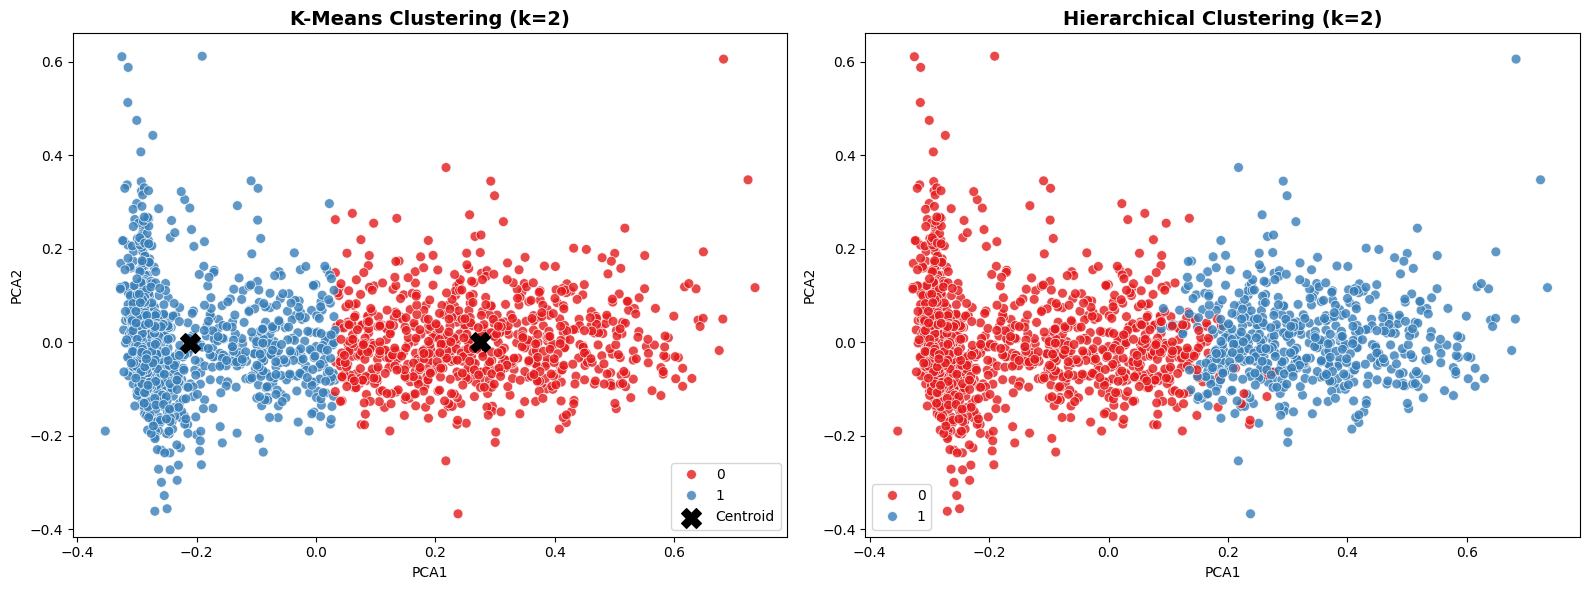


9. EVALUASI & KOMPARASI KINERJA MODEL



,Metode,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑)
0,K-Means (k=2),0.5180,0.7030,2952.3599
1,Hierarchical (k=2),0.4843,0.7088,2458.2465



10. PROFILING & INTERPRETASI KLASTER

-> Catatan: Nilai di bawah ini adalah nilai ASLI (sebelum log & scaling) agar mudah diinterpretasi.

--- Profil Karakteristik Klaster K-MEANS ---


,windspeed,temp,rh,pressure,rain,ta_max
KMeans_Cluster,,,,,,
0,1.12,27.19,84.36,1008.20,20.39,31.93
1,1.16,28.13,79.13,1008.05,0.63,32.46



--- Profil Karakteristik Klaster HIERARCHICAL ---


,windspeed,temp,rh,pressure,rain,ta_max
HC_Cluster,,,,,,
0,1.15,28.05,79.64,1008.10,1.45,32.43
1,1.13,27.06,85.02,1008.15,25.14,31.84



11. PENYIMPANAN DATA

[SUKSES] Dataset hasil clustering telah disimpan ke:
-> /content/drive/MyDrive/dataset/hasil_clustering_final_terbaik.csv


In [ ]:
# ==========================================
# IMPORT LIBRARY YANG DIBUTUHKAN
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

# Mengabaikan warning agar output skripsi terlihat rapi
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD DATA & HUBUNGKAN GOOGLE DRIVE
# ==========================================
print("==========================================")
print("1. PROSES LOADING DATA")
print("==========================================\n")

drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/dataset'
file_name = 'final_full_dataset' # Sesuaikan dengan nama file terbarumu

file_csv = os.path.join(folder_path, f'{file_name}.csv')
file_xlsx = os.path.join(folder_path, f'{file_name}.xlsx')

if os.path.exists(file_csv):
    df = pd.read_csv(file_csv)
    print("-> Berhasil memuat file CSV.")
elif os.path.exists(file_xlsx):
    df = pd.read_excel(file_xlsx)
    print("-> Berhasil memuat file Excel.")
else:
    raise FileNotFoundError("File tidak ditemukan! Pastikan path benar di Google Drive.")

print(f"\n[INFO] Dimensi Dataset: {df.shape[0]} Baris, {df.shape[1]} Kolom")

# ==========================================
# 2. PEMILIHAN FITUR & PENANGANAN MISSING VALUE
# ==========================================
print("\n==========================================")
print("2. PEMILIHAN FITUR & IMPUTASI MISSING VALUE")
print("==========================================\n")

if 'waktu' in df.columns:
    df['waktu'] = pd.to_datetime(df['waktu'])
    df = df.sort_values(by='waktu').reset_index(drop=True)

# Fitur final berdasarkan eksperimen dan uji korelasi
# ta_min dibuang (korelasi tinggi), winddir dibuang (data sirkular), variabel 0 dibuang
features =[
    'windspeed',
    'temp',
    'rh',
    'pressure',
    'rain',
    'ta_max'
]

# Cek dan tangani missing value
missing_before = df[features].isnull().sum()
if missing_before.sum() > 0:
    print("-> Melakukan Imputasi Interpolasi Linier untuk data time series harian...")
    df[features] = df[features].interpolate(method='linear').bfill().ffill()
else:
    print("-> Data bersih, tidak ditemukan missing value.")

# ==========================================
# 3. FEATURE ENGINEERING & NORMALISASI (MIN-MAX)
# ==========================================
print("\n==========================================")
print("3. TRANSFORMASI LOG & NORMALISASI (MIN-MAX SCALER)")
print("==========================================\n")

# Copy data agar df asli tidak berubah (untuk profiling nanti)
X = df[features].copy()

# Transformasi Logaritmik untuk Curah Hujan (Mengatasi Skewness/Outlier ekstrem)
X['rain'] = np.log1p(X['rain'])
print("-> Transformasi Logaritmik (log1p) diterapkan pada fitur 'rain'.")

# Normalisasi menggunakan MinMaxScaler (Terbukti empiris lebih baik untuk data ini)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
print("-> Normalisasi menggunakan MinMaxScaler selesai.")

# ==========================================
# 4. REDUKSI DIMENSI DENGAN PCA
# ==========================================
print("\n==========================================")
print("4. REDUKSI DIMENSI (PCA) SEBELUM CLUSTERING")
print("==========================================\n")

# Menggunakan PCA untuk mempertahankan 95% variansi data (membuang 5% noise)
pca_model = PCA(n_components=0.95, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)

n_pca_components = X_pca.shape[1]
print(f"-> PCA berhasil mereduksi dari {len(features)} fitur menjadi {n_pca_components} komponen utama.")
print(f"-> Komponen ini mempertahankan {sum(pca_model.explained_variance_ratio_)*100:.2f}% informasi asli.")

# ==========================================
# 5. PENENTUAN JUMLAH KLASTER OPTIMAL (K-MEANS)
# ==========================================
print("\n==========================================")
print("5. UJI JUMLAH KLASTER K-MEANS (PADA DATA PCA)")
print("==========================================\n")

wcss =[]
silhouette_scores_kmeans =[]
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_pca, kmeans.labels_))

# Plot Gabungan Elbow & Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:red'
ax1.set_xlabel('Jumlah Klaster (k)', fontsize=12)
ax1.set_ylabel('WCSS (Inertia)', color=color, fontsize=12)
ax1.plot(K_range, wcss, marker='o', color=color, linewidth=2, label='WCSS (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(K_range)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
ax2.plot(K_range, silhouette_scores_kmeans, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi Jumlah Klaster K-Means (Elbow vs Silhouette)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

best_k_kmeans = K_range[np.argmax(silhouette_scores_kmeans)]
print(f"=> Berdasarkan nilai Silhouette Score tertinggi, jumlah klaster K-Means optimal adalah K = {best_k_kmeans}")

# ==========================================
# 6. PENENTUAN JUMLAH KLASTER (HIERARCHICAL)
# ==========================================
print("\n==========================================")
print("6. PENENTUAN KLASTER HIERARCHICAL (DENDROGRAM)")
print("==========================================\n")

linkage_matrix = sch.linkage(X_pca, method='ward', metric='euclidean')

distances = linkage_matrix[:, 2]
jumps =[]
k_hc_range = list(range(2, 11))

for k in k_hc_range:
    jump = distances[-k+1] - distances[-k]
    jumps.append(jump)

best_k_hc = k_hc_range[np.argmax(jumps)]
cut_distance = distances[-best_k_hc]

plt.figure(figsize=(14, 6))
plt.title('Dendrogram Hierarchical Clustering (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Indeks Data Harian', fontsize=12)
plt.ylabel('Jarak Euclidean', fontsize=12)
dendrogram = sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.axhline(y=cut_distance, color='r', linestyle='--', linewidth=2, label=f'Garis Potong (k={best_k_hc})')
plt.legend()
plt.show()

print(f"=> Berdasarkan lonjakan jarak vertikal terbesar, klaster Hierarchical optimal adalah K = {best_k_hc}")

# ==========================================
# 7. IMPLEMENTASI MODEL FINAL
# ==========================================
print("\n==========================================")
print("7. IMPLEMENTASI CLUSTERING FINAL")
print("==========================================\n")

# K-MEANS FINAL
kmeans_final = KMeans(n_clusters=best_k_kmeans, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca)
df['KMeans_Cluster'] = kmeans_labels

# HIERARCHICAL FINAL
hc_final = AgglomerativeClustering(n_clusters=best_k_hc, metric='euclidean', linkage='ward')
hc_labels = hc_final.fit_predict(X_pca)
df['HC_Cluster'] = hc_labels

print("-> Model berhasil dieksekusi. Label telah ditambahkan ke dataset asli.")

# ==========================================
# 8. VISUALISASI HASIL (PCA 2D)
# ==========================================
print("\n==========================================")
print("8. VISUALISASI HASIL CLUSTERING (PCA 2D)")
print("==========================================\n")

# Mengambil 2 komponen pertama untuk visualisasi 2D
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', data=df, palette='Set1', ax=ax1, s=50, alpha=0.8)
centroids_pca = kmeans_final.cluster_centers_
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='black', label='Centroid')
ax1.set_title(f'K-Means Clustering (k={best_k_kmeans})', fontsize=14, fontweight='bold')
ax1.legend()

# Plot Hierarchical
sns.scatterplot(x='PCA1', y='PCA2', hue='HC_Cluster', data=df, palette='Set1', ax=ax2, s=50, alpha=0.8)
ax2.set_title(f'Hierarchical Clustering (k={best_k_hc})', fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 9. EVALUASI DAN KOMPARASI KEDUA METODE
# ==========================================
print("\n==========================================")
print("9. EVALUASI & KOMPARASI KINERJA MODEL")
print("==========================================\n")

eval_data = {
    'Metode':[f'K-Means (k={best_k_kmeans})', f'Hierarchical (k={best_k_hc})'],
    'Silhouette Score (↑)':[
        silhouette_score(X_pca, kmeans_labels),
        silhouette_score(X_pca, hc_labels)
    ],
    'Davies-Bouldin Index (↓)':[
        davies_bouldin_score(X_pca, kmeans_labels),
        davies_bouldin_score(X_pca, hc_labels)
    ],
    'Calinski-Harabasz Index (↑)':[
        calinski_harabasz_score(X_pca, kmeans_labels),
        calinski_harabasz_score(X_pca, hc_labels)
    ]
}

df_eval = pd.DataFrame(eval_data)
display(df_eval.round(4))

# ==========================================
# 10. INTERPRETASI KLASTER (PROFILING CUACA)
# ==========================================
print("\n==========================================")
print("10. PROFILING & INTERPRETASI KLASTER")
print("==========================================\n")

print("-> Catatan: Nilai di bawah ini adalah nilai ASLI (sebelum log & scaling) agar mudah diinterpretasi.")

print(f"\n--- Profil Karakteristik Klaster K-MEANS ---")
kmeans_profile = df.groupby('KMeans_Cluster')[features].mean()
display(kmeans_profile.round(2))

print(f"\n--- Profil Karakteristik Klaster HIERARCHICAL ---")
hc_profile = df.groupby('HC_Cluster')[features].mean()
display(hc_profile.round(2))

# ==========================================
# 11. OUTPUT AKHIR
# ==========================================
print("\n==========================================")
print("11. PENYIMPANAN DATA")
print("==========================================\n")

# Menghapus kolom PCA sementara sebelum disimpan
df_final_export = df.drop(columns=['PCA1', 'PCA2'])
output_path = os.path.join(folder_path, 'hasil_clustering_final_terbaik.csv')
df_final_export.to_csv(output_path, index=False)

print(f"[SUKSES] Dataset hasil clustering telah disimpan ke:")
print(f"-> {output_path}")

1. PROSES LOADING DATA

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-> Berhasil memuat file CSV.

[INFO] Dimensi Dataset: 1795 Baris, 7 Kolom

2. PEMILIHAN FITUR & IMPUTASI MISSING VALUE

-> Data bersih, tidak ditemukan missing value.

3. TRANSFORMASI LOG & NORMALISASI (MIN-MAX SCALER)

-> Transformasi Logaritmik (log1p) diterapkan pada fitur 'rain'.
-> Normalisasi menggunakan MinMaxScaler selesai.

4. REDUKSI DIMENSI (PCA) SEBELUM CLUSTERING

-> PCA berhasil mereduksi dari 6 fitur menjadi 3 komponen utama.
-> Komponen ini mempertahankan 96.04% informasi asli.

5. UJI JUMLAH KLASTER K-MEANS (PADA DATA PCA)



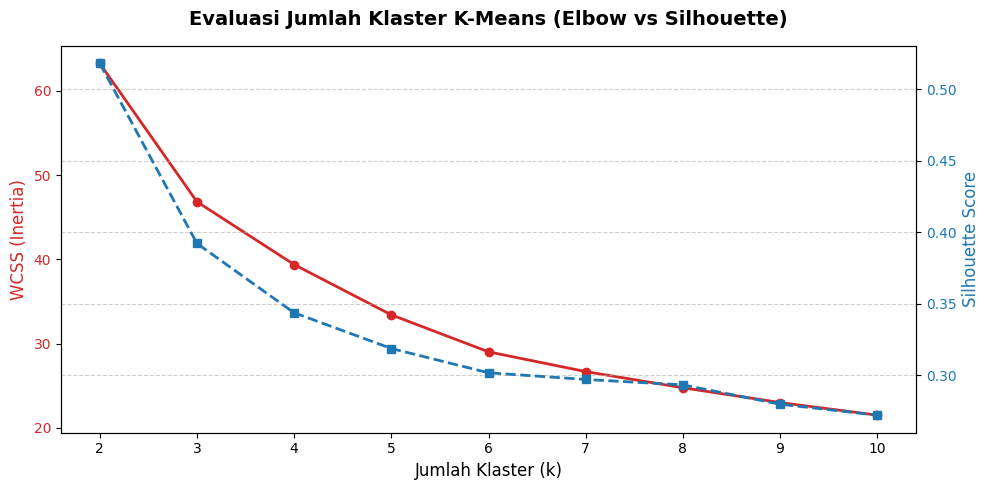

=> Berdasarkan nilai Silhouette Score tertinggi, jumlah klaster K-Means optimal adalah K = 2

6. PENENTUAN KLASTER HIERARCHICAL (DENDROGRAM)



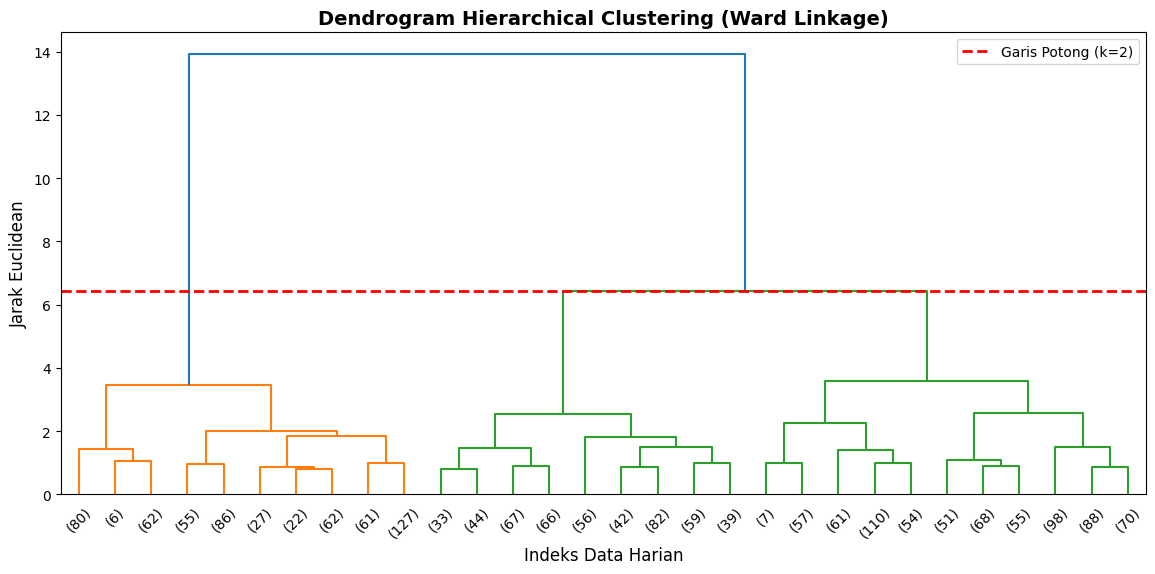

=> Berdasarkan lonjakan jarak vertikal terbesar, klaster Hierarchical optimal adalah K = 2

7. IMPLEMENTASI CLUSTERING FINAL

-> Model berhasil dieksekusi. Label telah ditambahkan ke dataset asli.

8. VISUALISASI HASIL CLUSTERING (PCA 2D)



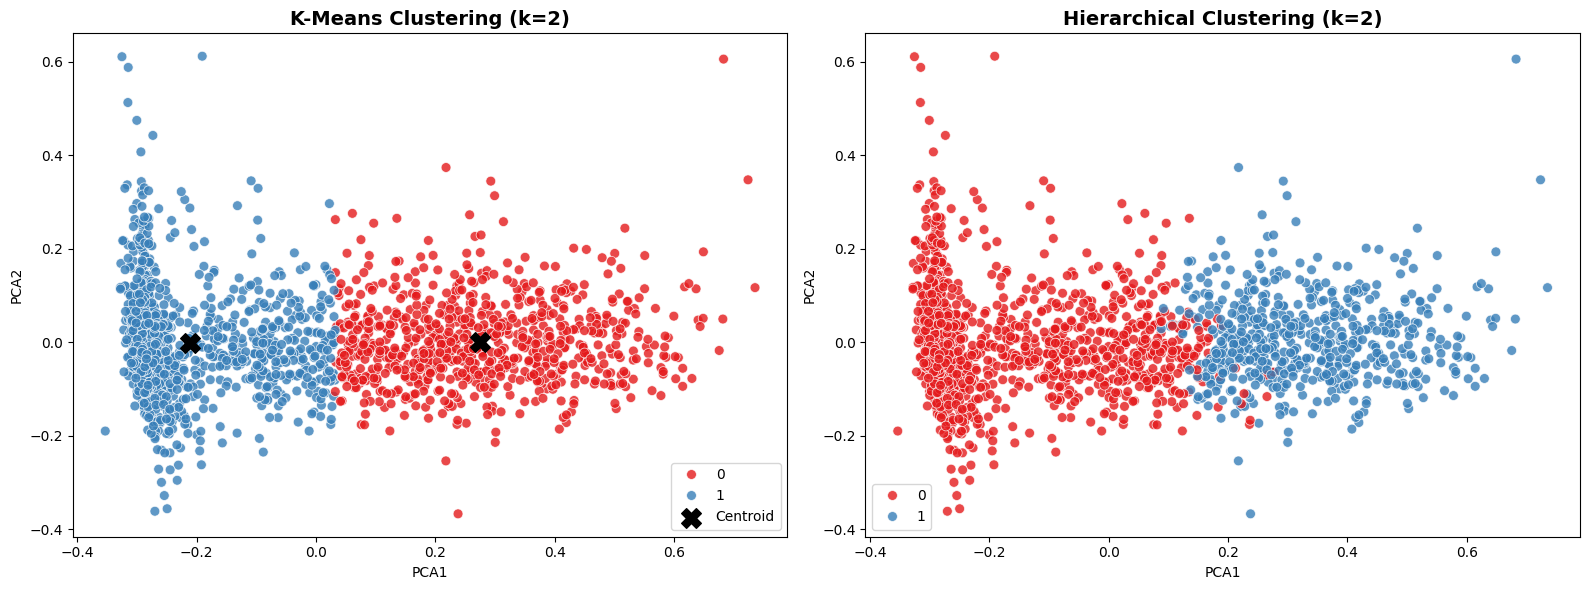


9. EVALUASI & KOMPARASI KINERJA MODEL



,Metode,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑)
0,K-Means (k=2),0.5180,0.7030,2952.2096
1,Hierarchical (k=2),0.4843,0.7088,2458.1305



10. PROFILING & INTERPRETASI KLASTER

-> Catatan: Nilai di bawah ini adalah nilai ASLI (sebelum log & scaling) agar mudah diinterpretasi.

--- Profil Karakteristik Klaster K-MEANS ---


,windspeed,temp,rh,pressure,rain,ta_max
KMeans_Cluster,,,,,,
0,1.12,27.19,84.36,1008.20,20.39,31.93
1,1.16,28.13,79.13,1008.05,0.63,32.46



--- Profil Karakteristik Klaster HIERARCHICAL ---


,windspeed,temp,rh,pressure,rain,ta_max
HC_Cluster,,,,,,
0,1.15,28.05,79.64,1008.10,1.45,32.43
1,1.13,27.06,85.02,1008.15,25.14,31.84



11. PENYIMPANAN DATA

[SUKSES] Dataset hasil clustering telah disimpan ke:
-> /content/drive/MyDrive/dataset/hasil_clustering_final_terbaik.csv


In [ ]:
# ==========================================
# IMPORT LIBRARY YANG DIBUTUHKAN
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

# Mengabaikan warning agar output skripsi terlihat rapi
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD DATA & HUBUNGKAN GOOGLE DRIVE
# ==========================================
print("==========================================")
print("1. PROSES LOADING DATA")
print("==========================================\n")

drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/dataset'
file_name = 'fix_noMissingValue' # Sesuaikan dengan nama file terbarumu

file_csv = os.path.join(folder_path, f'{file_name}.csv')
file_xlsx = os.path.join(folder_path, f'{file_name}.xlsx')

if os.path.exists(file_csv):
    df = pd.read_csv(file_csv)
    print("-> Berhasil memuat file CSV.")
elif os.path.exists(file_xlsx):
    df = pd.read_excel(file_xlsx)
    print("-> Berhasil memuat file Excel.")
else:
    raise FileNotFoundError("File tidak ditemukan! Pastikan path benar di Google Drive.")

print(f"\n[INFO] Dimensi Dataset: {df.shape[0]} Baris, {df.shape[1]} Kolom")

# ==========================================
# 2. PEMILIHAN FITUR & PENANGANAN MISSING VALUE
# ==========================================
print("\n==========================================")
print("2. PEMILIHAN FITUR & IMPUTASI MISSING VALUE")
print("==========================================\n")

if 'waktu' in df.columns:
    df['waktu'] = pd.to_datetime(df['waktu'])
    df = df.sort_values(by='waktu').reset_index(drop=True)

# Fitur final berdasarkan eksperimen dan uji korelasi
# ta_min dibuang (korelasi tinggi), winddir dibuang (data sirkular), variabel 0 dibuang
features =[
    'windspeed',
    'temp',
    'rh',
    'pressure',
    'rain',
    'ta_max'
]

# Cek dan tangani missing value
missing_before = df[features].isnull().sum()
if missing_before.sum() > 0:
    print("-> Melakukan Imputasi Interpolasi Linier untuk data time series harian...")
    df[features] = df[features].interpolate(method='linear').bfill().ffill()
else:
    print("-> Data bersih, tidak ditemukan missing value.")

# ==========================================
# 3. FEATURE ENGINEERING & NORMALISASI (MIN-MAX)
# ==========================================
print("\n==========================================")
print("3. TRANSFORMASI LOG & NORMALISASI (MIN-MAX SCALER)")
print("==========================================\n")

# Copy data agar df asli tidak berubah (untuk profiling nanti)
X = df[features].copy()

# Transformasi Logaritmik untuk Curah Hujan (Mengatasi Skewness/Outlier ekstrem)
X['rain'] = np.log1p(X['rain'])
print("-> Transformasi Logaritmik (log1p) diterapkan pada fitur 'rain'.")

# Normalisasi menggunakan MinMaxScaler (Terbukti empiris lebih baik untuk data ini)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
print("-> Normalisasi menggunakan MinMaxScaler selesai.")

# ==========================================
# 4. REDUKSI DIMENSI DENGAN PCA
# ==========================================
print("\n==========================================")
print("4. REDUKSI DIMENSI (PCA) SEBELUM CLUSTERING")
print("==========================================\n")

# Menggunakan PCA untuk mempertahankan 95% variansi data (membuang 5% noise)
pca_model = PCA(n_components=0.95, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)

n_pca_components = X_pca.shape[1]
print(f"-> PCA berhasil mereduksi dari {len(features)} fitur menjadi {n_pca_components} komponen utama.")
print(f"-> Komponen ini mempertahankan {sum(pca_model.explained_variance_ratio_)*100:.2f}% informasi asli.")

# ==========================================
# 5. PENENTUAN JUMLAH KLASTER OPTIMAL (K-MEANS)
# ==========================================
print("\n==========================================")
print("5. UJI JUMLAH KLASTER K-MEANS (PADA DATA PCA)")
print("==========================================\n")

wcss =[]
silhouette_scores_kmeans =[]
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_pca, kmeans.labels_))

# Plot Gabungan Elbow & Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:red'
ax1.set_xlabel('Jumlah Klaster (k)', fontsize=12)
ax1.set_ylabel('WCSS (Inertia)', color=color, fontsize=12)
ax1.plot(K_range, wcss, marker='o', color=color, linewidth=2, label='WCSS (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(K_range)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
ax2.plot(K_range, silhouette_scores_kmeans, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi Jumlah Klaster K-Means (Elbow vs Silhouette)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

best_k_kmeans = K_range[np.argmax(silhouette_scores_kmeans)]
print(f"=> Berdasarkan nilai Silhouette Score tertinggi, jumlah klaster K-Means optimal adalah K = {best_k_kmeans}")

# ==========================================
# 6. PENENTUAN JUMLAH KLASTER (HIERARCHICAL)
# ==========================================
print("\n==========================================")
print("6. PENENTUAN KLASTER HIERARCHICAL (DENDROGRAM)")
print("==========================================\n")

linkage_matrix = sch.linkage(X_pca, method='ward', metric='euclidean')

distances = linkage_matrix[:, 2]
jumps =[]
k_hc_range = list(range(2, 11))

for k in k_hc_range:
    jump = distances[-k+1] - distances[-k]
    jumps.append(jump)

best_k_hc = k_hc_range[np.argmax(jumps)]
cut_distance = distances[-best_k_hc]

plt.figure(figsize=(14, 6))
plt.title('Dendrogram Hierarchical Clustering (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Indeks Data Harian', fontsize=12)
plt.ylabel('Jarak Euclidean', fontsize=12)
dendrogram = sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.axhline(y=cut_distance, color='r', linestyle='--', linewidth=2, label=f'Garis Potong (k={best_k_hc})')
plt.legend()
plt.show()

print(f"=> Berdasarkan lonjakan jarak vertikal terbesar, klaster Hierarchical optimal adalah K = {best_k_hc}")

# ==========================================
# 7. IMPLEMENTASI MODEL FINAL
# ==========================================
print("\n==========================================")
print("7. IMPLEMENTASI CLUSTERING FINAL")
print("==========================================\n")

# K-MEANS FINAL
kmeans_final = KMeans(n_clusters=best_k_kmeans, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca)
df['KMeans_Cluster'] = kmeans_labels

# HIERARCHICAL FINAL
hc_final = AgglomerativeClustering(n_clusters=best_k_hc, metric='euclidean', linkage='ward')
hc_labels = hc_final.fit_predict(X_pca)
df['HC_Cluster'] = hc_labels

print("-> Model berhasil dieksekusi. Label telah ditambahkan ke dataset asli.")

# ==========================================
# 8. VISUALISASI HASIL (PCA 2D)
# ==========================================
print("\n==========================================")
print("8. VISUALISASI HASIL CLUSTERING (PCA 2D)")
print("==========================================\n")

# Mengambil 2 komponen pertama untuk visualisasi 2D
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', data=df, palette='Set1', ax=ax1, s=50, alpha=0.8)
centroids_pca = kmeans_final.cluster_centers_
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='black', label='Centroid')
ax1.set_title(f'K-Means Clustering (k={best_k_kmeans})', fontsize=14, fontweight='bold')
ax1.legend()

# Plot Hierarchical
sns.scatterplot(x='PCA1', y='PCA2', hue='HC_Cluster', data=df, palette='Set1', ax=ax2, s=50, alpha=0.8)
ax2.set_title(f'Hierarchical Clustering (k={best_k_hc})', fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 9. EVALUASI DAN KOMPARASI KEDUA METODE
# ==========================================
print("\n==========================================")
print("9. EVALUASI & KOMPARASI KINERJA MODEL")
print("==========================================\n")

eval_data = {
    'Metode':[f'K-Means (k={best_k_kmeans})', f'Hierarchical (k={best_k_hc})'],
    'Silhouette Score (↑)':[
        silhouette_score(X_pca, kmeans_labels),
        silhouette_score(X_pca, hc_labels)
    ],
    'Davies-Bouldin Index (↓)':[
        davies_bouldin_score(X_pca, kmeans_labels),
        davies_bouldin_score(X_pca, hc_labels)
    ],
    'Calinski-Harabasz Index (↑)':[
        calinski_harabasz_score(X_pca, kmeans_labels),
        calinski_harabasz_score(X_pca, hc_labels)
    ]
}

df_eval = pd.DataFrame(eval_data)
display(df_eval.round(4))

# ==========================================
# 10. INTERPRETASI KLASTER (PROFILING CUACA)
# ==========================================
print("\n==========================================")
print("10. PROFILING & INTERPRETASI KLASTER")
print("==========================================\n")

print("-> Catatan: Nilai di bawah ini adalah nilai ASLI (sebelum log & scaling) agar mudah diinterpretasi.")

print(f"\n--- Profil Karakteristik Klaster K-MEANS ---")
kmeans_profile = df.groupby('KMeans_Cluster')[features].mean()
display(kmeans_profile.round(2))

print(f"\n--- Profil Karakteristik Klaster HIERARCHICAL ---")
hc_profile = df.groupby('HC_Cluster')[features].mean()
display(hc_profile.round(2))

# ==========================================
# 11. OUTPUT AKHIR
# ==========================================
print("\n==========================================")
print("11. PENYIMPANAN DATA")
print("==========================================\n")

# Menghapus kolom PCA sementara sebelum disimpan
df_final_export = df.drop(columns=['PCA1', 'PCA2'])
output_path = os.path.join(folder_path, 'hasil_clustering_final_terbaik.csv')
df_final_export.to_csv(output_path, index=False)

print(f"[SUKSES] Dataset hasil clustering telah disimpan ke:")
print(f"-> {output_path}")

1. PROSES LOADING DATA

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-> Berhasil memuat file CSV.

[INFO] Dimensi Dataset Awal: 1795 Baris, 7 Kolom

2. PEMILIHAN FITUR & PEMBERSIHAN DATA

-> Mengecek missing value...
-> Data bersih, tidak ditemukan missing value.

3. TRANSFORMASI LOG & NORMALISASI (MIN-MAX SCALER)

-> Transformasi Logaritmik (log1p) diterapkan pada fitur 'rain'.
-> Normalisasi menggunakan MinMaxScaler selesai.

4. REDUKSI DIMENSI (PCA) SEBELUM CLUSTERING

-> PCA berhasil mereduksi dari 6 fitur menjadi 3 komponen utama.
-> Komponen ini mempertahankan 96.04% informasi asli.

5. UJI JUMLAH KLASTER K-MEANS (PADA DATA PCA)



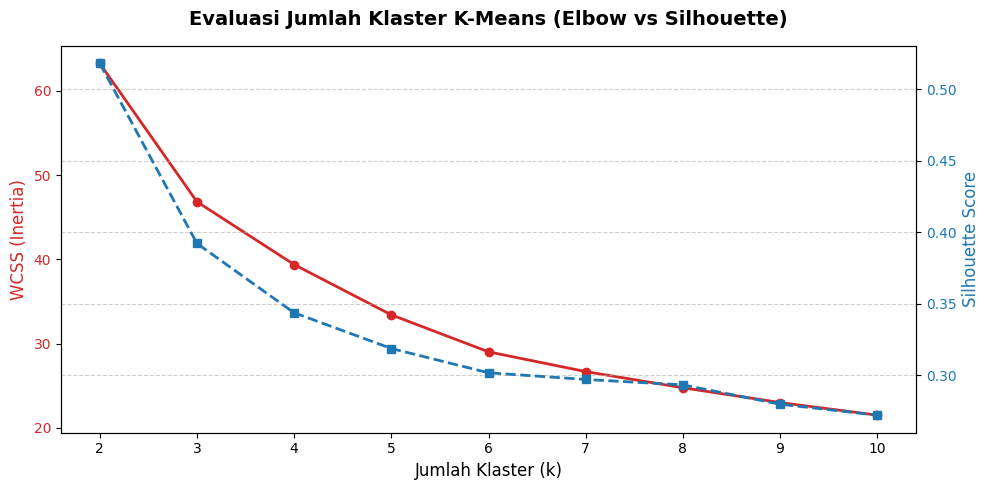

=> Berdasarkan nilai Silhouette Score tertinggi, jumlah klaster K-Means optimal adalah K = 2

6. PENENTUAN KLASTER HIERARCHICAL (DENDROGRAM)



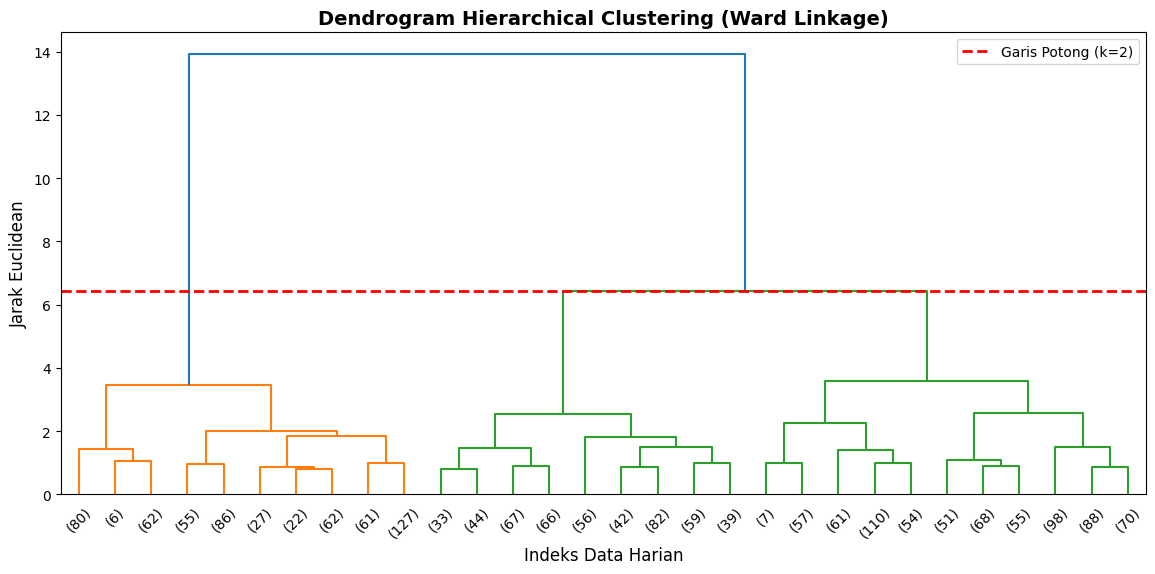

=> Berdasarkan lonjakan jarak vertikal terbesar, klaster Hierarchical optimal adalah K = 2

7. IMPLEMENTASI CLUSTERING FINAL

-> Model berhasil dieksekusi. Label telah ditambahkan ke dataset asli.

8. VISUALISASI HASIL CLUSTERING (PCA 2D)



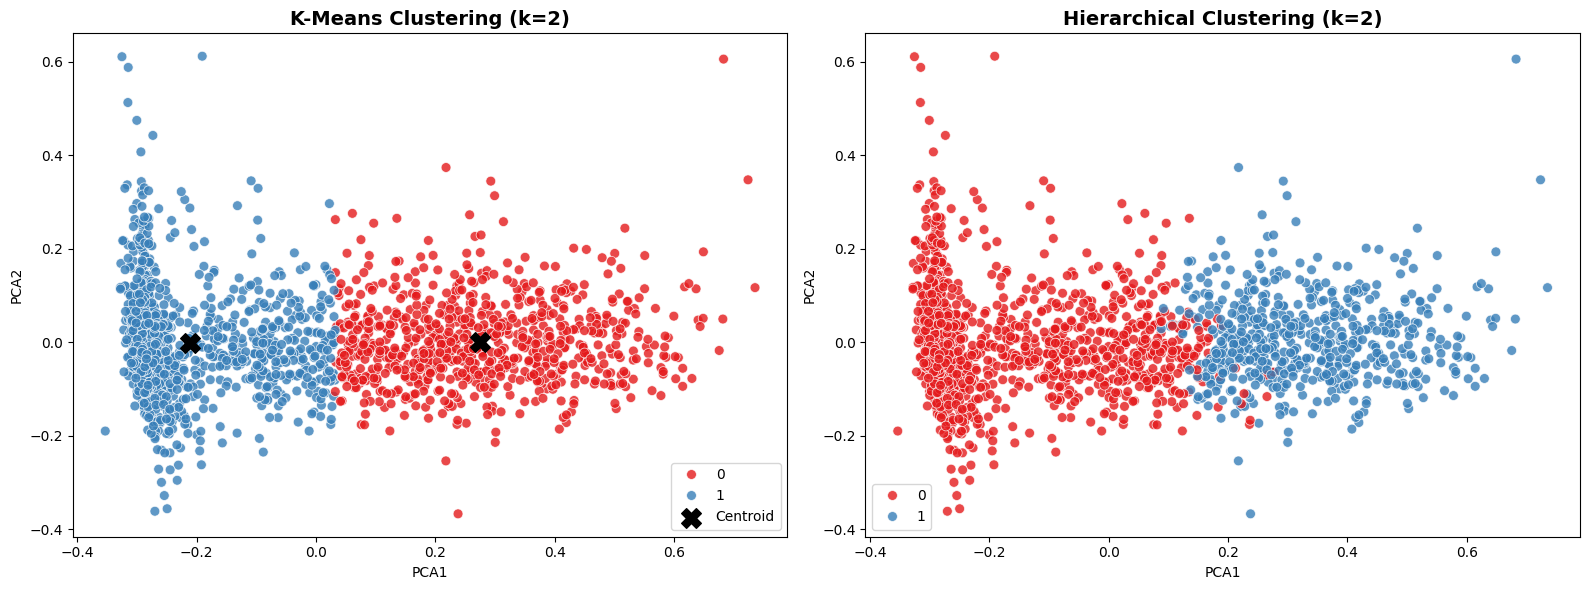


9. EVALUASI & KOMPARASI KINERJA MODEL



,Metode,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑)
0,K-Means (k=2),0.5180,0.7030,2952.2096
1,Hierarchical (k=2),0.4843,0.7088,2458.1305



10. PROFILING & INTERPRETASI KLASTER


--- Profil Karakteristik Klaster K-MEANS ---


,windspeed,temp,rh,pressure,rain,ta_max
KMeans_Cluster,,,,,,
0,1.12,27.19,84.36,1008.20,20.39,31.93
1,1.16,28.13,79.13,1008.05,0.63,32.46



--- Profil Karakteristik Klaster HIERARCHICAL ---


,windspeed,temp,rh,pressure,rain,ta_max
HC_Cluster,,,,,,
0,1.15,28.05,79.64,1008.10,1.45,32.43
1,1.13,27.06,85.02,1008.15,25.14,31.84



11. PENYIMPANAN DATA

-> Mengecek sisa missing value sebelum ekspor...
-> Konfirmasi: Data 100% bersih (0 Missing Value).

[SUKSES] Dataset hasil clustering telah disimpan ke:
-> /content/drive/MyDrive/dataset/hasil_clustering_final_terbaik.csv
Jumlah baris akhir: 1795


In [ ]:
# ==========================================
# IMPORT LIBRARY YANG DIBUTUHKAN
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

# Mengabaikan warning agar output skripsi terlihat rapi
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD DATA & HUBUNGKAN GOOGLE DRIVE
# ==========================================
print("==========================================")
print("1. PROSES LOADING DATA")
print("==========================================\n")

drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/dataset'
file_name = 'fix_noMissingValue' # Sesuaikan dengan nama file terbarumu
file_csv = os.path.join(folder_path, f'{file_name}.csv')
file_xlsx = os.path.join(folder_path, f'{file_name}.xlsx')

if os.path.exists(file_csv):
    df = pd.read_csv(file_csv)
    print("-> Berhasil memuat file CSV.")
elif os.path.exists(file_xlsx):
    df = pd.read_excel(file_xlsx)
    print("-> Berhasil memuat file Excel.")
else:
    raise FileNotFoundError("File tidak ditemukan! Pastikan path benar di Google Drive.")

print(f"\n[INFO] Dimensi Dataset Awal: {df.shape[0]} Baris, {df.shape[1]} Kolom")

# ==========================================
# 2. PEMILIHAN FITUR & PENANGANAN MISSING VALUE (TOTAL CLEANING)
# ==========================================
print("\n==========================================")
print("2. PEMILIHAN FITUR & PEMBERSIHAN DATA")
print("==========================================\n")

# A. Tangani kolom waktu
if 'waktu' in df.columns:
    # Pastikan tidak ada baris yang kolom waktunya kosong
    df = df.dropna(subset=['waktu'])
    df['waktu'] = pd.to_datetime(df['waktu'])
    df = df.sort_values(by='waktu').reset_index(drop=True)

# B. Definisikan Fitur
features = ['windspeed', 'temp', 'rh', 'pressure', 'rain', 'ta_max']

# C. Pembersihan Missing Value di SELURUH KOLOM
print("-> Mengecek missing value...")
missing_total = df.isnull().sum().sum()

if missing_total > 0:
    print(f"-> Ditemukan {missing_total} missing value. Melakukan imputasi pada seluruh kolom numerik...")
    # Imputasi hanya pada kolom numerik menggunakan interpolasi
    cols_numeric = df.select_dtypes(include=[np.number]).columns
    df[cols_numeric] = df[cols_numeric].interpolate(method='linear').bfill().ffill()

    # Jika masih ada sisa missing value (misal di kolom kategori/string), hapus baris tersebut
    if df.isnull().sum().sum() > 0:
        df = df.dropna()
    print("-> Data sekarang sudah bersih.")
else:
    print("-> Data bersih, tidak ditemukan missing value.")

# ==========================================
# 3. FEATURE ENGINEERING & NORMALISASI (MIN-MAX)
# ==========================================
print("\n==========================================")
print("3. TRANSFORMASI LOG & NORMALISASI (MIN-MAX SCALER)")
print("==========================================\n")

# Copy data agar df asli tidak berubah (untuk profiling nanti)
X = df[features].copy()

# Transformasi Logaritmik untuk Curah Hujan
X['rain'] = np.log1p(X['rain'])
print("-> Transformasi Logaritmik (log1p) diterapkan pada fitur 'rain'.")

# Normalisasi menggunakan MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
print("-> Normalisasi menggunakan MinMaxScaler selesai.")

# ==========================================
# 4. REDUKSI DIMENSI DENGAN PCA
# ==========================================
print("\n==========================================")
print("4. REDUKSI DIMENSI (PCA) SEBELUM CLUSTERING")
print("==========================================\n")

pca_model = PCA(n_components=0.95, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)
n_pca_components = X_pca.shape[1]

print(f"-> PCA berhasil mereduksi dari {len(features)} fitur menjadi {n_pca_components} komponen utama.")
print(f"-> Komponen ini mempertahankan {sum(pca_model.explained_variance_ratio_)*100:.2f}% informasi asli.")

# ==========================================
# 5. PENENTUAN JUMLAH KLASTER OPTIMAL (K-MEANS)
# ==========================================
print("\n==========================================")
print("5. UJI JUMLAH KLASTER K-MEANS (PADA DATA PCA)")
print("==========================================\n")

wcss = []
silhouette_scores_kmeans = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_pca, kmeans.labels_))

# Plot Gabungan Elbow & Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:red'
ax1.set_xlabel('Jumlah Klaster (k)', fontsize=12)
ax1.set_ylabel('WCSS (Inertia)', color=color, fontsize=12)
ax1.plot(K_range, wcss, marker='o', color=color, linewidth=2, label='WCSS (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(K_range)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
ax2.plot(K_range, silhouette_scores_kmeans, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi Jumlah Klaster K-Means (Elbow vs Silhouette)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

best_k_kmeans = K_range[np.argmax(silhouette_scores_kmeans)]
print(f"=> Berdasarkan nilai Silhouette Score tertinggi, jumlah klaster K-Means optimal adalah K = {best_k_kmeans}")

# ==========================================
# 6. PENENTUAN JUMLAH KLASTER (HIERARCHICAL)
# ==========================================
print("\n==========================================")
print("6. PENENTUAN KLASTER HIERARCHICAL (DENDROGRAM)")
print("==========================================\n")

linkage_matrix = sch.linkage(X_pca, method='ward', metric='euclidean')
distances = linkage_matrix[:, 2]
jumps = []
k_hc_range = list(range(2, 11))

for k in k_hc_range:
    jump = distances[-k+1] - distances[-k]
    jumps.append(jump)

best_k_hc = k_hc_range[np.argmax(jumps)]
cut_distance = distances[-best_k_hc]

plt.figure(figsize=(14, 6))
plt.title('Dendrogram Hierarchical Clustering (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Indeks Data Harian', fontsize=12)
plt.ylabel('Jarak Euclidean', fontsize=12)
dendrogram = sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.axhline(y=cut_distance, color='r', linestyle='--', linewidth=2, label=f'Garis Potong (k={best_k_hc})')
plt.legend()
plt.show()

print(f"=> Berdasarkan lonjakan jarak vertikal terbesar, klaster Hierarchical optimal adalah K = {best_k_hc}")

# ==========================================
# 7. IMPLEMENTASI MODEL FINAL
# ==========================================
print("\n==========================================")
print("7. IMPLEMENTASI CLUSTERING FINAL")
print("==========================================\n")

# K-MEANS FINAL
kmeans_final = KMeans(n_clusters=best_k_kmeans, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca)
df['KMeans_Cluster'] = kmeans_labels

# HIERARCHICAL FINAL
hc_final = AgglomerativeClustering(n_clusters=best_k_hc, metric='euclidean', linkage='ward')
hc_labels = hc_final.fit_predict(X_pca)
df['HC_Cluster'] = hc_labels

print("-> Model berhasil dieksekusi. Label telah ditambahkan ke dataset asli.")

# ==========================================
# 8. VISUALISASI HASIL (PCA 2D)
# ==========================================
print("\n==========================================")
print("8. VISUALISASI HASIL CLUSTERING (PCA 2D)")
print("==========================================\n")

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', data=df, palette='Set1', ax=ax1, s=50, alpha=0.8)
centroids_pca = kmeans_final.cluster_centers_
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='black', label='Centroid')
ax1.set_title(f'K-Means Clustering (k={best_k_kmeans})', fontsize=14, fontweight='bold')
ax1.legend()

# Plot Hierarchical
sns.scatterplot(x='PCA1', y='PCA2', hue='HC_Cluster', data=df, palette='Set1', ax=ax2, s=50, alpha=0.8)
ax2.set_title(f'Hierarchical Clustering (k={best_k_hc})', fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 9. EVALUASI DAN KOMPARASI KEDUA METODE
# ==========================================
print("\n==========================================")
print("9. EVALUASI & KOMPARASI KINERJA MODEL")
print("==========================================\n")

eval_data = {
    'Metode': [f'K-Means (k={best_k_kmeans})', f'Hierarchical (k={best_k_hc})'],
    'Silhouette Score (↑)': [
        silhouette_score(X_pca, kmeans_labels),
        silhouette_score(X_pca, hc_labels)
    ],
    'Davies-Bouldin Index (↓)': [
        davies_bouldin_score(X_pca, kmeans_labels),
        davies_bouldin_score(X_pca, hc_labels)
    ],
    'Calinski-Harabasz Index (↑)': [
        calinski_harabasz_score(X_pca, kmeans_labels),
        calinski_harabasz_score(X_pca, hc_labels)
    ]
}
df_eval = pd.DataFrame(eval_data)
display(df_eval.round(4))

# ==========================================
# 10. INTERPRETASI KLASTER (PROFILING CUACA)
# ==========================================
print("\n==========================================")
print("10. PROFILING & INTERPRETASI KLASTER")
print("==========================================\n")

print(f"\n--- Profil Karakteristik Klaster K-MEANS ---")
kmeans_profile = df.groupby('KMeans_Cluster')[features].mean()
display(kmeans_profile.round(2))

print(f"\n--- Profil Karakteristik Klaster HIERARCHICAL ---")
hc_profile = df.groupby('HC_Cluster')[features].mean()
display(hc_profile.round(2))

# ==========================================
# 11. OUTPUT AKHIR (DENGAN PENGECEKAN MISSING VALUE)
# ==========================================
print("\n==========================================")
print("11. PENYIMPANAN DATA")
print("==========================================\n")

# Cek terakhir kali sebelum simpan
print("-> Mengecek sisa missing value sebelum ekspor...")
final_nan_check = df.isnull().sum().sum()

if final_nan_check == 0:
    print("-> Konfirmasi: Data 100% bersih (0 Missing Value).")
else:
    print(f"-> PERINGATAN: Masih ada {final_nan_check} missing value. Melakukan drop baris terakhir...")
    df = df.dropna()

# Menghapus kolom PCA sementara sebelum disimpan
df_final_export = df.drop(columns=['PCA1', 'PCA2'])

output_path = os.path.join(folder_path, 'hasil_clustering_final_terbaik.csv')
df_final_export.to_csv(output_path, index=False)

print(f"\n[SUKSES] Dataset hasil clustering telah disimpan ke:")
print(f"-> {output_path}")
print(f"Jumlah baris akhir: {df_final_export.shape[0]}")